In [1]:
import scanpy as sc
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
import re
import numpy as np
import anndata as ad
import gseapy as gp

from perturbgen.configs import ROOT
import textwrap
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

In [2]:
# set wd
os.chdir(ROOT)
print('Current working directory:', ROOT)

Current working directory: /lustre/scratch126/cellgen/lotfollahi/kl11


In [3]:
res_dir = '/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/OT'
# create directory if it does not exist
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

In [4]:
style.use('default')
style.use(
    '/lustre/scratch126/cellgen/lotfollahi/kl11/'
    'T_perturb/perturbgen/pp/mpl_style.mplstyle'
)

In [5]:
ot_df = pd.read_csv('hematological_disorders_annotated.csv')

In [6]:
all_programs = ot_df.cluster.unique()

In [7]:
ot_df

,Unnamed: 0,ensembl_id,genes,cluster,disease_id,disease_name,therapeutic_area_name,therapeutic_area_id,association_score,disease_ancestors,chembl,eva,gene_burden,genomics_england,gwas_credible_sets,lineage_category,disease_name_clean
0,92796,ENSG00000141510,TP53,Core transcription regulation,MONDO_0018875,Li-Fraumeni syndrome,"genetic, familial or congenital disease",OTAR_0000018,0.864446,"MONDO_0023370, OTAR_0000018, MONDO_0045024, MO...",NaN,0.969042,NaN,0.947176,NaN,Systemic/Developmental,Li-Fraumeni Syndrome
1,92425,ENSG00000141510,TP53,Core transcription regulation,EFO_0000095,chronic lymphocytic leukemia,hematologic disease,EFO_0005803,0.860234,"EFO_0001642, EFO_0000220, EFO_1000068, EFO_000...",0.121586,NaN,0.660781,NaN,NaN,Lymphoid disorder,Chronic Lymphocytic Leukemia
2,139087,ENSG00000171316,CHD7,Fetal megakaryocyte - erythroid maturation,MONDO_0008965,CHARGE syndrome,"genetic, familial or congenital disease",OTAR_0000018,0.850025,"OTAR_0000017, MONDO_0018555, MONDO_0100547, EF...",NaN,0.948930,NaN,0.976169,NaN,Systemic/Developmental,CHARGE Syndrome
3,133533,ENSG00000168769,TET2,Core transcription regulation,EFO_0000198,myelodysplastic syndrome,cancer or benign tumor,MONDO_0045024,0.827629,"EFO_0005803, MONDO_0023370, MONDO_0002334, MON...",NaN,0.774151,0.983552,NaN,NaN,Myeloid disorder,Myelodysplastic Syndrome
4,119711,ENSG00000162711,NLRP3,Immune response to external stimuli,MONDO_0011776,CINCA syndrome,"genetic, familial or congenital disease",OTAR_0000018,0.824096,"EFO_0002461, MONDO_0019751, EFO_0000540, OTAR_...",NaN,0.885388,NaN,0.928567,NaN,Immunodeficiency,CINCA Syndrome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18472,88455,ENSG00000139508,SLC46A3,NF-kB signaling and B cell activation,EFO_0022910,ebv-positive nodal t- and nk-cell lymphoma,cancer or benign tumor,MONDO_0045024,0.000000,"MONDO_0045024, EFO_0000616, EFO_0000508, OTAR_...",NaN,0.000000,NaN,NaN,NaN,Lymphoid disorder,EBV-Positive Nodal T- and NK-Cell Lymphoma
18473,53512,ENSG00000116017,ARID3A,Vesicle and organelle localization,EFO_0022910,ebv-positive nodal t- and nk-cell lymphoma,hematologic disease,EFO_0005803,0.000000,"MONDO_0045024, EFO_0000616, EFO_0000508, OTAR_...",NaN,0.000000,NaN,NaN,NaN,Lymphoid disorder,EBV-Positive Nodal T- and NK-Cell Lymphoma
18474,88803,ENSG00000139618,BRCA2,Mitotic cell cycle,EFO_0022910,ebv-positive nodal t- and nk-cell lymphoma,hematologic disease,EFO_0005803,0.000000,"MONDO_0045024, EFO_0000616, EFO_0000508, OTAR_...",NaN,0.000000,NaN,NaN,NaN,Lymphoid disorder,EBV-Positive Nodal T- and NK-Cell Lymphoma
18475,72387,ENSG00000130508,PXDN,Core transcription regulation,EFO_0022910,ebv-positive nodal t- and nk-cell lymphoma,hematologic disease,EFO_0005803,0.000000,"MONDO_0045024, EFO_0000616, EFO_0000508, OTAR_...",NaN,0.000000,NaN,NaN,NaN,Lymphoid disorder,EBV-Positive Nodal T- and NK-Cell Lymphoma


In [8]:
ot_df.cluster.unique()

array(['Core transcription regulation',
       'Fetal megakaryocyte - erythroid maturation',
       'Immune response to external stimuli', 'Lymphocyte activation-2',
       'Myeloid Differentiation', 'Hypoxia-2',
       'Antigen presentation and immune response', 'Mitotic cell cycle',
       'Early lympho-myeloid differentiation',
       'Vesicle and organelle localization',
       'Early megakaryocyte - erythroid differentiation',
       'Fetal hematopoietic progenitor proliferation',
       'Myeloid leukocyte activation',
       'Postnatal lymphoid differentiation', 'Lymphocyte activation-1',
       'Antigen processing and presentation',
       'Fetal hemostasis and platelet activation',
       'NF-kB signaling and B cell activation', 'Hypoxia-1',
       'Pediatric HSC and lymphoid progenitor proliferation'],
      dtype=object)

In [9]:
ot_measurement_filtered_df = ot_df[
    (ot_df['gwas_credible_sets'] >= 0.25 # filter locus_to_gene score
    )
]

In [10]:
ot_diseases_filtered_df = ot_df[
    (ot_df['gwas_credible_sets'] >= 0.5 # filter locus_to_gene score
    )  | 
    (
        ot_df['eva'] >= 0.5  # 0.5 at least risk factor https://platform-docs.opentargets.org/evidence#clinvar
    ) |
    (
        ot_df['gene_burden'] >= 0.5
    ) |
    (
        ot_df['genomics_england'] >= 0.5
    ) 
]

In [11]:
ot_df[ot_df['cluster'] == 'Early megakaryocyte - erythroid differentiation'].disease_name.unique()

array(['Glanzmann thrombasthenia 1', 'Bernard-Soulier syndrome',
       'thrombocytopenia, X-linked, with or without dyserythropoietic anemia',
       'Rh deficiency syndrome',
       'congenital dyserythropoietic anemia type 4',
       'X-linked dyserythropoetic anemia with abnormal platelets and neutropenia',
       'platelet-type von Willebrand disease',
       'overhydrated hereditary stomatocytosis',
       'platelet-type bleeding disorder 17', 'platelet volume',
       'reticulocyte count', 'reticulocyte amount', 'platelet count',
       'platelet component distribution width',
       'hemolytic anemia due to erythrocyte adenosine deaminase overproduction',
       'Blackfan-Diamond anemia',
       'beta-thalassemia-X-linked thrombocytopenia syndrome',
       'erythrocyte volume', 'mean corpuscular hemoglobin',
       'thrombocytopenia, anemia, and myelofibrosis',
       'Diamond-Blackfan anemia', 'mean reticulocyte volume',
       'Glanzmann thrombasthenia', 'bleeding disorder, p

In [ ]:
memp_cats = ['megakaryocytic', 'erythroid', 'basophilic/eosinophilic']
lymphoid_cats = ['lymphoid']
myeloid_cats = ['myeloid (granulocytic)', 'myeloid (monocytic)']

cats = {
    'meg-erythro': memp_cats,
    'lymphoid': lymphoid_cats,
    'myeloid': myeloid_cats,
    'all': memp_cats + lymphoid_cats + myeloid_cats
}

# flatten cats.values() to get all unique lineage categories
all_lineages = [cat for sublist in cats.values() for cat in sublist]
lineage_palette = sns.color_palette("tab10", n_colors=len(all_lineages))
lineage_color_lut = dict(zip(all_lineages, lineage_palette))
lineage_color_lut = {
    'megakaryocytic': '#6a8abd',
    'basophilic/eosinophilic': '#e73f3a',
    'erythroid':'#744195',
    'lymphoid': '#1663ad',
    'myeloid (granulocytic)': '#a63461',
    'myeloid (monocytic)': '#eee2e2',
}


for program in all_programs:
    df_program = ot_df[ot_df['cluster'] == program]

    for name, cat in cats.items():

        # row order according to lineage category
        order = []
        for celltype in cat:
            order.extend(
                ot_df.loc[ot_df.lineage_category == celltype, 'disease_name']
                .unique()
                .tolist()
            )

        lineage_dir = f"{res_dir}/{name}_all"
        os.makedirs(lineage_dir, exist_ok=True)

        df_plot = df_program[df_program['lineage_category'].isin(cat)]
        if df_plot.empty:
            continue

        df_plot = df_plot.sort_values(by='lineage_category')

        # pivot: diseases = rows, genes = columns
        df_pivot = df_plot.pivot(
            index='disease_name',
            columns='genes',
            values='gwas_credible_sets'
        ).fillna(0)

        # enforce your disease ordering
        df_pivot = df_pivot.reindex(index=order)

        # remove empty rows
        df_pivot = df_pivot.dropna(how='all')
        if df_pivot.empty:
            continue
        # --------- lineage color bar for diseases (rows) ----------
        disease_to_lineage = (
            ot_df[['disease_name', 'lineage_category']]
            .drop_duplicates(subset='disease_name')
            .set_index('disease_name')['lineage_category']
        )
        # 2. Align this *after* you’ve finished all reindexing of df_pivot
        disease_lineage_aligned = disease_to_lineage.reindex(df_pivot.index)

        # Optional sanity check: these should match exactly
        assert len(df_pivot.index) == len(disease_lineage_aligned)
        assert disease_lineage_aligned.isna().sum() == 0, "Some diseases missing lineage!"

        # 3. Map to colors and wrap in a DataFrame (safer for clustermap)
        row_colors = disease_lineage_aligned.map(lineage_color_lut)
        row_colors_df = row_colors.to_frame(name='Lineage')


        # sizes based on matrix shape (robust)
        n_rows, n_cols = df_pivot.shape

        fig_width = min(max(8, 0.4 * n_cols), 30)
        fig_height = min(max(8, 0.28 * n_rows), 20)

        # ----- CLUSTERMAP -----
        g = sns.clustermap(
            df_pivot,
            cmap='viridis',    # "viridis"
            col_cluster=True,       # cluster genes
            row_cluster=False,      # DO NOT cluster diseases\            
            row_colors=row_colors_df,
            figsize=(fig_width, fig_height),
            vmin=0,               
            vmax=1,
            cbar_kws={'label': 'Locus2Gene score',
                       'ticks': [0, 0.25, 0.5, 0.75, 1.0]     # ✔️ compresses colorbar into threshold + gradient
                      }
        )
        g.fig.subplots_adjust(right=0.8)  # shrink heatmap/dendrogram to 80% width
        # shrink lineage_category label
        g.ax_row_colors.set_ylabel("Lineage category",fontsize=10)   # or smaller
        # Remove ONLY the x-axis label below the row_colors bar
        g.ax_row_colors.set_xlabel("")       # remove text
        g.ax_row_colors.set_xticks([])       # remove ticks
        g.ax_row_colors.set_xticklabels([])  # remove tick labels

        # tighten to remove ugly whitespace
        g.gs.update(top=0.96, bottom=0.06, left=0.25, right=0.8)

        # axes labels
        g.ax_heatmap.set_xlabel("Genes", fontsize=10)
        g.ax_heatmap.set_ylabel("Disease", fontsize=10)

        # create legend for lineage colors
        legend_handles = [
            Patch(color=color, label=lineage)
            for lineage, color in lineage_color_lut.items()
        ]
        g.ax_heatmap.legend(
            handles=legend_handles,
            title="Lineage Category",
            bbox_to_anchor=(1.1, 1),
            loc='upper left',
            borderaxespad=0.,
            fontsize=6,
            title_fontsize=10
        )
        g.ax_cbar.set_position([
            g.ax_cbar.get_position().x0 + 0.03,   # move right slightly
            g.ax_cbar.get_position().y0,
            g.ax_cbar.get_position().width * 0.3, # narrower
            g.ax_cbar.get_position().height       # same height
        ])
        # Smaller colorbar ticks + label
        g.ax_cbar.tick_params(labelsize=6)
        g.ax_cbar.set_ylabel("Locus2Gene score", fontsize=10)
        # # AFTER: Wrap the y-axis labels drawn by clustermap
        # new_labels = [
        #     "\n".join(textwrap.wrap(tick.get_text(), width=35))
        #     for tick in g.ax_heatmap.get_yticklabels()
        # ]
        # Force one tick per gene
        n_genes = df_pivot.shape[1]
        # Get column order after clustering
        col_order = g.dendrogram_col.reordered_ind
        cols_reordered = df_pivot.columns[col_order]

        # Force one tick per gene, in clustered order
        g.ax_heatmap.set_xticks(np.arange(len(cols_reordered)) + 0.5)
        g.ax_heatmap.set_xticklabels(cols_reordered, rotation=90, fontsize=6)

        # Force one tick per gene, in clustered order
        # y-axis labels (diseases after clustering or reordering)
        y_labels = row_colors_df.index.tolist()

        # wrap each label to width N characters
        wrapped_y_labels = [
            "\n".join(textwrap.wrap(label, width=30))   # ← adjust width as needed
            for label in y_labels
        ]

        # set ticks + wrapped labels
        g.ax_heatmap.set_yticks(np.arange(len(wrapped_y_labels)) + 0.5)
        g.ax_heatmap.set_yticklabels(wrapped_y_labels, rotation=0, fontsize=6)
        # g.ax_heatmap.set_yticklabels(new_labels, rotation=0)
        # tick styles
        g.ax_heatmap.tick_params(axis='x', rotation=90, labelsize=6)
        g.ax_heatmap.tick_params(axis='y', rotation=0, labelsize=6)
        # for lh in g.ax_row_dendrogram.get_legend().legendHandles:
        #     lh.set_sizes([20])   # marker size (smaller)

        # legend = g.ax_row_dendrogram.get_legend()
        # legend.prop.set_size(6)  # legend text size
        # legend.get_title().set_fontsize(7)
        safe_program = re.sub(r'[^A-Za-z0-9]+', '_', program).strip('_')
        # save df_pivot
        df_pivot.to_csv(
            f"{lineage_dir}/OT_heatmap_{safe_program}.csv"
        )


        # save
        
        g.fig.savefig(
            f"{lineage_dir}/OT_heatmap_{safe_program}.pdf",
            dpi=300,
            bbox_inches="tight"
        )
        plt.close(g.fig)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap
from matplotlib.patches import Patch


all_programs = ot_measurement_filtered_df.cluster.unique()

memp_cats = ['megakaryocytic', 'erythroid', 'basophilic/eosinophilic']
lymphoid_cats = ['lymphoid']
myeloid_cats = ['myeloid (granulocytic)', 'myeloid (monocytic)']

cats = {
    'meg-erythro': memp_cats,
    'lymphoid': lymphoid_cats,
    'myeloid': myeloid_cats,
    'all': memp_cats + lymphoid_cats + myeloid_cats
}

base = plt.get_cmap("viridis")

n_colors = 256
n_flat = n_colors // 4       # 0.0–0.25
n_grad = n_colors - n_flat   # 0.25–1.0

# flat color = viridis at 0.5  (so the threshold color matches old plot)
flat_color = base(0.0)

# first half: all the same color
colors_flat = np.tile(flat_color, (n_flat, 1))

# second half: viridis from 0.25 to 1.0 -> preserves colors for v>=0.25
colors_grad = base(np.linspace(0.25, 1.0, n_grad))

colors = np.vstack([colors_flat, colors_grad])

flat_viridis_05 = ListedColormap(colors, name="flat_0_05_viridis")

# flatten cats.values() to get all unique lineage categories
all_lineages = [cat for sublist in cats.values() for cat in sublist]
lineage_palette = sns.color_palette("tab10", n_colors=len(all_lineages))
lineage_color_lut = dict(zip(all_lineages, lineage_palette))
lineage_color_lut = {
    'megakaryocytic': '#6a8abd',
    'basophilic/eosinophilic': '#e73f3a',
    'erythroid':'#744195',
    'lymphoid': '#1663ad',
    'myeloid (granulocytic)': '#a63461',
    'myeloid (monocytic)': '#eee2e2',
}

for program in all_programs:
    df_program = ot_measurement_filtered_df[ot_measurement_filtered_df['cluster'] == program]

    for name, cat in cats.items():

        # row order according to lineage category
        order = []
        for celltype in cat:
            order.extend(
                ot_measurement_filtered_df.loc[ot_measurement_filtered_df.lineage_category == celltype, 'disease_name']
                .unique()
                .tolist()
            )

        lineage_dir = f"{res_dir}/{name}_filtered"
        os.makedirs(lineage_dir, exist_ok=True)

        df_plot = df_program[df_program['lineage_category'].isin(cat)]
        if df_plot.empty:
            continue

        df_plot = df_plot.sort_values(by='lineage_category')

        # pivot: diseases = rows, genes = columns
        df_pivot = df_plot.pivot(
            index='disease_name',
            columns='genes',
            values='gwas_credible_sets'
        ).fillna(0)

        # enforce your disease ordering
        df_pivot = df_pivot.reindex(index=order)

        # remove empty rows
        df_pivot = df_pivot.dropna(how='all')
        if df_pivot.empty:
            continue
        # --------- lineage color bar for diseases (rows) ----------
        disease_to_lineage = (
            ot_measurement_filtered_df[['disease_name', 'lineage_category']]
            .drop_duplicates(subset='disease_name')
            .set_index('disease_name')['lineage_category']
        )
        # 2. Align this *after* you’ve finished all reindexing of df_pivot
        disease_lineage_aligned = disease_to_lineage.reindex(df_pivot.index)

        # Optional sanity check: these should match exactly
        assert len(df_pivot.index) == len(disease_lineage_aligned)
        assert disease_lineage_aligned.isna().sum() == 0, "Some diseases missing lineage!"

        # 3. Map to colors and wrap in a DataFrame (safer for clustermap)
        row_colors = disease_lineage_aligned.map(lineage_color_lut)
        row_colors_df = row_colors.to_frame(name='Lineage')


        # sizes based on matrix shape (robust)
        n_rows, n_cols = df_pivot.shape

        fig_width = min(max(8, 0.4 * n_cols), 30)
        fig_height = min(max(8, 0.28 * n_rows), 20)

        # ----- CLUSTERMAP -----
        g = sns.clustermap(
            df_pivot,
            cmap=flat_viridis_05,    # "viridis"
            col_cluster=True,       # cluster genes
            row_cluster=False,      # DO NOT cluster diseases
            vmin=0,                # IMPORTANT
            vmax=1,            
            row_colors=row_colors_df,
            figsize=(fig_width, fig_height),
                cbar_kws={
                    'label': 'Locus2Gene score',
                    'ticks': [0, 0.25, 0.5, 0.75, 1.0]
                    }
            )


        g.fig.subplots_adjust(right=0.8)  # shrink heatmap/dendrogram to 80% width
        # shrink lineage_category label
        g.ax_row_colors.set_ylabel("Lineage category",fontsize=10)   # or smaller
        # Remove ONLY the x-axis label below the row_colors bar
        g.ax_row_colors.set_xlabel("")       # remove text
        g.ax_row_colors.set_xticks([])       # remove ticks
        g.ax_row_colors.set_xticklabels([])  # remove tick labels



        # tighten to remove ugly whitespace
        g.gs.update(top=0.96, bottom=0.06, left=0.25, right=0.8)

        # axes labels
        g.ax_heatmap.set_xlabel("Genes", fontsize=10)
        g.ax_heatmap.set_ylabel("Disease", fontsize=10)

        # create legend for lineage colors
        legend_handles = [
            Patch(color=color, label=lineage)
            for lineage, color in lineage_color_lut.items()
        ]
        g.ax_heatmap.legend(
            handles=legend_handles,
            title="Lineage Category",
            bbox_to_anchor=(1.1, 1),
            loc='upper left',
            borderaxespad=0.,
            fontsize=6,
            title_fontsize=10
        )
        g.ax_cbar.set_position([
            g.ax_cbar.get_position().x0 + 0.03,   # move right slightly
            g.ax_cbar.get_position().y0,
            g.ax_cbar.get_position().width * 0.3, # narrower
            g.ax_cbar.get_position().height       # same height
        ])
        # Smaller colorbar ticks + label
        g.ax_cbar.tick_params(labelsize=6)
        g.ax_cbar.set_ylabel("Locus2Gene score", fontsize=10)
        # # AFTER: Wrap the y-axis labels drawn by clustermap
        # new_labels = [
        #     "\n".join(textwrap.wrap(tick.get_text(), width=35))
        #     for tick in g.ax_heatmap.get_yticklabels()
        # ]
        # Force one tick per gene
        n_genes = df_pivot.shape[1]
        # Get column order after clustering
        col_order = g.dendrogram_col.reordered_ind
        cols_reordered = df_pivot.columns[col_order]

        # Force one tick per gene, in clustered order
        g.ax_heatmap.set_xticks(np.arange(len(cols_reordered)) + 0.5)
        g.ax_heatmap.set_xticklabels(cols_reordered, rotation=90, fontsize=6)

        # Force one tick per gene, in clustered order
        # y-axis labels (diseases after clustering or reordering)
        y_labels = row_colors_df.index.tolist()

        # wrap each label to width N characters
        wrapped_y_labels = [
            "\n".join(textwrap.wrap(label, width=30))   # ← adjust width as needed
            for label in y_labels
        ]

        # set ticks + wrapped labels
        g.ax_heatmap.set_yticks(np.arange(len(wrapped_y_labels)) + 0.5)
        g.ax_heatmap.set_yticklabels(wrapped_y_labels, rotation=0, fontsize=6)
        # g.ax_heatmap.set_yticklabels(new_labels, rotation=0)
        # tick styles
        g.ax_heatmap.tick_params(axis='x', rotation=90, labelsize=6)
        g.ax_heatmap.tick_params(axis='y', rotation=0, labelsize=6)
        # for lh in g.ax_row_dendrogram.get_legend().legendHandles:
        #     lh.set_sizes([20])   # marker size (smaller)

        # legend = g.ax_row_dendrogram.get_legend()
        # legend.prop.set_size(6)  # legend text size
        # legend.get_title().set_fontsize(7)
        safe_program = re.sub(r'[^A-Za-z0-9]+', '_', program).strip('_')
        
        # save df_pivot
        df_pivot.to_csv(
            f"{lineage_dir}/OT_heatmap_{safe_program}.csv"
        )


        # save
        
        g.fig.savefig(
            f"{lineage_dir}/OT_heatmap_{safe_program}.pdf",
            dpi=300,
            bbox_inches="tight"
        )
        plt.close(g.fig)


In [13]:
disease_df = ot_diseases_filtered_df[ot_diseases_filtered_df['therapeutic_area_name']!='measurement']

In [14]:
disease_df.groupby(['cluster', 'lineage_category'])['disease_name_clean'].nunique()

cluster                                   lineage_category                
Antigen presentation and immune response  Immunodeficiency                    9
                                          MK/Platelet disorder                1
                                          Systemic/Developmental              1
Antigen processing and presentation       Immunodeficiency                    1
                                          Lymphoid disorder                   4
                                                                             ..
Vesicle and organelle localization        MK/Platelet disorder                4
                                          Mixed or Haematopoietic disorder    2
                                          Myeloid disorder                    1
                                          Red Cell disorder                   3
                                          Systemic/Developmental              1
Name: disease_name_clean, Length: 92, dtype: 

/tmp/ipykernel_2856000/2070340916.py:105: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


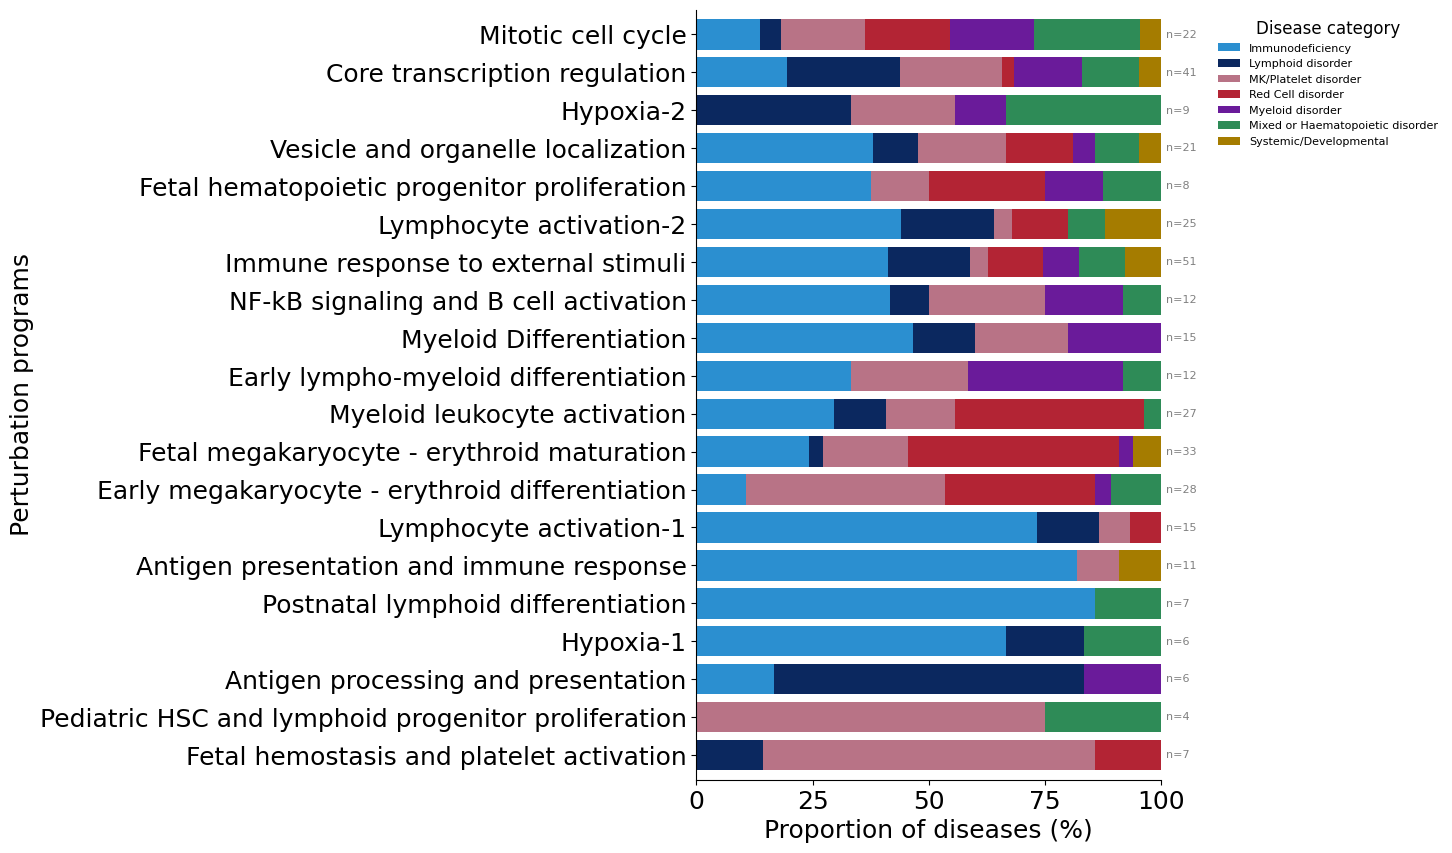

In [ ]:

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

order = ['Mixed or Haematopoietic disorder', 'Red Cell disorder', 'MK/Platelet disorder', 'Myeloid disorder','Lymphoid disorder','Immunodeficiency','Systemic/Developmental']
# colour palette for the lineage categories in the desired order
palette = sns.color_palette("tab10", n_colors=len(order))
lineage_color_lut = dict(zip(order, palette))
lineage_color_lut = {
    'Mixed or Haematopoietic disorder': "#2E8B57",
    'Systemic/Developmental': "#A57C00",
    'Red Cell disorder': "#B32434",
    'MK/Platelet disorder': "#b87386",      # lighter, saturated blue
    'Myeloid disorder': "#6A1B9A",
    'Lymphoid disorder': "#0B285F",         # deep navy for strong contrast
    'Immunodeficiency': "#2B8FD0",
    
}
# desired stacking order (left to right)
sort_order = [
    'Immunodeficiency',
    'Lymphoid disorder',
    'MK/Platelet disorder',
    'Red Cell disorder',
    'Myeloid disorder',
    'Mixed or Haematopoietic disorder',
    'Systemic/Developmental'
]


# count unique diseases per cluster and lineage category
disease_counts = (
    disease_df
    .groupby(['cluster', 'lineage_category'])['disease_name_clean']
    .nunique()
    .unstack(fill_value=0)
)

# compute total number of diseases per cluster (for annotation)
n_diseases = disease_counts.sum(axis=1)

# convert counts to proportions (row-wise)
disease_props = disease_counts.div(n_diseases, axis=0)

# compute distance matrix on proportions
dist = pdist(disease_props[sort_order].values, metric='euclidean')

# hierarchical clustering
Z = linkage(dist, method='average')

# get clustered row order
cluster_order = disease_props.index[leaves_list(Z)]

# reorder data
disease_props = disease_props.loc[cluster_order]
n_diseases = n_diseases.loc[cluster_order]


# ensure all categories exist
for c in sort_order:
    if c not in disease_props.columns:
        disease_props[c] = 0.0

# reorder columns to control stacking
disease_props = disease_props[sort_order]
# plot 100% stacked horizontal bar plot
fig, ax = plt.subplots(figsize=(6, 10))

disease_props.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=[lineage_color_lut[c] for c in disease_props.columns],
    width=0.8
)

# x-axis as percentage
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(['0', '25', '50', '75', '100'])

ax.set_xlabel('Proportion of diseases (%)')
ax.set_ylabel('Perturbation programs')

# annotate total number of diseases (n) at bar end
for i, (cluster, n) in enumerate(n_diseases.items()):
    ax.text(
        1.01,                # slightly outside the bar
        i,
        f'n={n}',
        va='center',
        ha='left',
        fontsize=8,
        color='gray'
    )

# legend outside
ax.legend(
    title='Disease category',
    bbox_to_anchor=(1.1, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=12
)

plt.tight_layout()
disease_dir = f"{res_dir}/disease"
plt.savefig(
    f"{disease_dir}/disease_counts_per_program_filtered.pdf", 
    dpi=300,
    bbox_inches="tight"
    )

In [15]:
def scaled_font(base, fig_width, fig_height, ref_w=20, ref_h=20,
                min_fs=5, max_fs=14):
    """
    Scale font size with figure size.

    base   : base font size (for a 'normal' figure).
    ref_w  : width (inches) we consider 'normal'.
    ref_h  : height (inches) we consider 'normal'.
    """
    scale_w = fig_width / ref_w
    scale_h = fig_height / ref_h
    scale = min(scale_w, scale_h, 1.0)  # never grow fonts above base
    fs = base * scale
    return max(min_fs, min(max_fs, fs))


In [ ]:
order = ['Mixed or Haematopoietic disorder', 'Red Cell disorder', 'MK/Platelet disorder', 'Myeloid disorder','Lymphoid disorder','Immunodeficiency','Systemic/Developmental']
# colour palette for the lineage categories in the desired order
palette = sns.color_palette("tab10", n_colors=len(order))
lineage_color_lut = dict(zip(order, palette))
lineage_color_lut = {
    'Mixed or Haematopoietic disorder': "#ba7783",
    'Red Cell disorder': "#4A1070",
    'MK/Platelet disorder': "#2957a1",
    'Myeloid disorder': "#870d3e",
    'Lymphoid disorder': "#053969",
    'Immunodeficiency': "#0a7b28",
    'Systemic/Developmental': "#a77f0a",
}

disease_dir = f"{res_dir}/disease"
for program in all_programs:
    
    df_plot = ot_diseases_filtered_df[ot_diseases_filtered_df['therapeutic_area_name'] != 'measurement']
    
    df_plot = df_plot[df_plot['cluster'] == program]


    if df_plot.empty:
        continue
    sorter_index = {k: v for v, k in enumerate(order)}
    # sort lineage categories by your given order
    df_plot['lineage_sort'] = df_plot['lineage_category'].map(sorter_index)
    
    df_plot = df_plot.sort_values(by='lineage_sort', ascending=True)
    # aggregate if multiple entries per genes-disease_name


    # pivot: genes (rows) x diseases (columns)
    df_pivot = df_plot.pivot_table(
        index='genes',
        columns='disease_name_clean',
        values='association_score',
        aggfunc='max'
    ).fillna(0)

    # keep disease columns in original order
    column_order = df_plot['disease_name_clean'].unique().tolist()
    df_pivot = df_pivot.reindex(columns=column_order)

    # drop empty rows/cols
    df_pivot = df_pivot.dropna(how='all', axis=0)
    df_pivot = df_pivot.dropna(how='all', axis=1)
    if df_pivot.empty:
        continue
    # ----- build col_colors from lineage_category (per disease) -----
    disease_to_lineage = (
        df_plot[['disease_name_clean', 'lineage_category']]
        .drop_duplicates(subset='disease_name_clean')
        .set_index('disease_name_clean')['lineage_category']
    )

    # align to df_pivot columns
    disease_to_lineage = disease_to_lineage.reindex(df_pivot.columns)
    row_colors = disease_to_lineage.map(lineage_color_lut)

    # ---- figure size control ----
    n_rows, n_cols = df_pivot.shape
    height_per_row = 0.45
    width_per_col = 0.45
    min_width, min_height = 10, 6
    max_width, max_height = 70, 50

    fig_width = min(max(n_cols * width_per_col, min_width), max_width)
    fig_height = min(max(n_rows * height_per_row, min_height), max_height)
    # choose sizes
    label_fs   = scaled_font(12, fig_width, fig_height)  # axis labels
    tick_fs    = scaled_font(10,  fig_width, fig_height)  # tick labels
    legend_fs  = scaled_font(10,  fig_width, fig_height)  # legend text
    cbar_fs    = scaled_font(10,  fig_width, fig_height)  # colorbar ticks
    cbar_lab_fs= scaled_font(12, fig_width, fig_height)  # colorbar label    

    # ---- clustermap ----
    g = sns.clustermap(
        df_pivot.T,
        cmap='viridis',
        row_cluster=False,          # cluster genes if you like
        col_cluster=True,         
        row_colors=row_colors,     # << color bar for columns
        figsize=(fig_width, fig_height),
        vmin=0,
        vmax=1,
        cbar_kws={'label': 'Association score',
                     'ticks': [0, 0.25, 0.5, 0.75, 1.0]
                    }
    )
    g.fig.subplots_adjust(right=0.8)  # shrink heatmap/dendrogram to 80% width

    # axis labels
    g.ax_heatmap.set_xlabel('Disease', fontsize=label_fs)
    g.ax_heatmap.set_ylabel('Genes', fontsize=label_fs)

    # row_colors label
    g.ax_row_colors.set_ylabel("Disease category", fontsize=label_fs)
    g.ax_row_colors.set_xlabel("")
    g.ax_row_colors.set_xticks([])
    g.ax_row_colors.set_xticklabels([])

    # x tick labels (genes) – use clustered order
    col_order = g.dendrogram_col.reordered_ind
    cols_reordered = df_pivot.index[col_order]
    g.ax_heatmap.set_xticks(np.arange(len(cols_reordered)) + 0.5)
    g.ax_heatmap.set_xticklabels(cols_reordered, rotation=90, fontsize=tick_fs)

    # y tick labels (diseases)
    y_labels = row_colors.index.tolist()
    g.ax_heatmap.set_yticks(np.arange(len(y_labels)) + 0.5)
    g.ax_heatmap.set_yticklabels(y_labels, rotation=0, fontsize=tick_fs)

    # tick params (can use same tick_fs)
    g.ax_heatmap.tick_params(axis='x', labelsize=tick_fs)
    g.ax_heatmap.tick_params(axis='y', labelsize=tick_fs)

    # legend for lineage categories
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=lineage_color_lut[l], label=l) for l in order]
    g.ax_col_dendrogram.legend(
        handles=handles,
        title='Lineage category',
        title_fontsize=legend_fs,   # <── Add this
        bbox_to_anchor=(1.1, 1),
        loc='upper left',
        borderaxespad=0.,
        prop={'size': legend_fs}
    )

    # colorbar
    g.ax_cbar.set_position([
        g.ax_cbar.get_position().x0 + 0.03,
        g.ax_cbar.get_position().y0,
        g.ax_cbar.get_position().width * 0.3,
        g.ax_cbar.get_position().height
    ])
    g.ax_cbar.tick_params(labelsize=cbar_fs)
    g.ax_cbar.set_ylabel("OT association score", fontsize=cbar_lab_fs)
    

    safe_program = re.sub(r'[^A-Za-z0-9]+', '_', program).strip('_')
    # save df_pivot
    df_pivot.T.to_csv(
        f"{disease_dir}/OT_heatmap_disease_{safe_program}.csv"
    )
    g.fig.savefig(
        f'{disease_dir}/OT_heatmap_disease_{safe_program}.pdf',
        dpi=300,
        bbox_inches='tight'
    )
    plt.close(g.fig)

Fischer exact hypergeometric test

In [17]:
adata_clustered = sc.read_h5ad('T_perturb/res/hspc/perturbation_5k_res/summary_plots/20250723_leiden_pert_cls_annotated.h5ad')
adata_clustered_obs = adata_clustered.obs

In [18]:
adata_clustered.obs

,genes,leiden,ensembl_id,GP_name_old,GP_name
1,ARID4A,0,ENSG00000032219,Activated antigen-presenting myeloid cells,Antigen processing and presentation
3,ZNF76,1,ENSG00000065029,Transcription regulation,Core transcription regulation
6,COG3,3,ENSG00000136152,Transcription regulation,Protein ubiquitination and vesicle transport
11,PREB,5,ENSG00000138073,Core transcription control,Core transcription regulation
14,ZNF846,6,ENSG00000196605,Core transcription control,Core transcription regulation
...,...,...,...,...,...
5560,ZFX,4,ENSG00000005889,Transcription regulation,Vesicle and organelle localization
5561,RBM38,11,ENSG00000132819,Lymphocyte activation,Lymphocyte differentiation
5563,ABCA1,12,ENSG00000165029,Cell Migration,Immune response to external stimuli
5564,CARD19,9,ENSG00000165233,Cell cycle/chromatin remodelling,Pediatric HSC and lymphoid progenitor prolifer...


In [19]:
disease_dict = (
    disease_df.groupby('lineage_category')['genes']
        .unique()
        .apply(list)
        .to_dict()
)

In [21]:
adata_clustered_obs

,genes,leiden,ensembl_id,GP_name_old,GP_name
1,ARID4A,0,ENSG00000032219,Activated antigen-presenting myeloid cells,Antigen processing and presentation
3,ZNF76,1,ENSG00000065029,Transcription regulation,Core transcription regulation
6,COG3,3,ENSG00000136152,Transcription regulation,Protein ubiquitination and vesicle transport
11,PREB,5,ENSG00000138073,Core transcription control,Core transcription regulation
14,ZNF846,6,ENSG00000196605,Core transcription control,Core transcription regulation
...,...,...,...,...,...
5560,ZFX,4,ENSG00000005889,Transcription regulation,Vesicle and organelle localization
5561,RBM38,11,ENSG00000132819,Lymphocyte activation,Lymphocyte differentiation
5563,ABCA1,12,ENSG00000165029,Cell Migration,Immune response to external stimuli
5564,CARD19,9,ENSG00000165233,Cell cycle/chromatin remodelling,Pediatric HSC and lymphoid progenitor prolifer...


In [22]:
adata_clustered_obs.GP_name.value_counts()

GP_name
Core transcription regulation                          785
Immune response to external stimuli                    403
Fetal hematopoietic progenitor proliferation           141
Lymphocyte differentiation                             111
Myeloid Differentiation                                109
Signaling pathways in fetal innate immune cells        106
Antigen presentation and immune response                96
Myeloid leukocyte activation                            95
Lymphocyte activation-2                                 94
Mitotic cell cycle                                      93
Protein transport                                       92
NF-kB signaling and B cell activation                   91
Vesicle and organelle localization                      86
Fetal hemostasis and platelet activation                82
Antigen processing and presentation                     79
Early megakaryocyte - erythroid differentiation         79
Fetal megakaryocyte - erythroid maturation      

In [23]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

def global_cluster_enrichment(
    df,
    disease_dict,
    gene_col='gene',
    cluster_col='cluster',
    alternative='greater'
):
    """
    Perform Fisher enrichment for all cluster × disease combinations
    and apply global FDR correction.
    """

    N = len(df)
    universe_genes = set(df[gene_col])
    clusters = df.groupby(cluster_col)

    results = []

    for disease_name, gene_list in disease_dict.items():

        disease_set = set(gene_list).intersection(universe_genes)
        total_disease = len(disease_set)

        # Skip empty disease sets
        if total_disease == 0:
            continue

        disease_flag = df[gene_col].isin(disease_set).astype(int)


        for cluster_name, subdf in clusters:

            cluster_idx = subdf.index
            cluster_size = len(subdf)

            a = disease_flag.loc[cluster_idx].sum()
            b = cluster_size - a
            c = total_disease - a
            d = (N - cluster_size) - c

            table = [[a, b],
                     [c, d]]

            odds_ratio, pval = fisher_exact(table, alternative=alternative)
            expected = cluster_size * total_disease / N

            results.append({
                'cluster': cluster_name,
                'disease': disease_name,
                'cluster_size': cluster_size,
                'disease_set_size': total_disease,
                'disease_in_cluster': a,
                'expected_in_cluster': expected,
                'odds_ratio': odds_ratio,
                'p_value': pval
            })

    results_df = pd.DataFrame(results)

    # Global FDR across ALL tests
    results_df['FDR_global'] = multipletests(
        results_df['p_value'],
        method='fdr_bh'
    )[1]

    return results_df.sort_values('FDR_global')

In [24]:
enrichment_df = global_cluster_enrichment(
    adata_clustered_obs,
    disease_dict,
    gene_col='genes',
    cluster_col='GP_name',
    alternative='greater'
)

/tmp/ipykernel_1952830/1678018317.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clusters = df.groupby(cluster_col)


In [25]:
enrichment_df[enrichment_df.FDR_global < 0.3]

,cluster,disease,cluster_size,disease_set_size,disease_in_cluster,expected_in_cluster,odds_ratio,p_value,FDR_global
11,Lymphocyte activation-1,Immunodeficiency,59,107,11,2.031864,7.046875,0.000003,0.000372
54,Early megakaryocyte - erythroid differentiation,MK/Platelet disorder,79,52,9,1.322176,8.925249,0.000004,0.000372
132,Fetal megakaryocyte - erythroid maturation,Red Cell disorder,79,30,6,0.762794,10.287671,0.000081,0.004752
26,Antigen processing and presentation,Lymphoid disorder,79,45,5,1.144191,5.047297,0.005156,0.223487
129,Early megakaryocyte - erythroid differentiation,Red Cell disorder,79,30,4,0.762794,6.157949,0.006419,0.223487
162,Lymphocyte activation-2,Systemic/Developmental,94,14,3,0.423560,8.997003,0.007662,0.223487


In [26]:
for key, values in disease_dict.items():
    print(key, len(values))

Immunodeficiency 107
Lymphoid disorder 45
MK/Platelet disorder 52
Mixed or Haematopoietic disorder 28
Myeloid disorder 19
Red Cell disorder 30
Systemic/Developmental 14


Magma Matrix

In [ ]:
adata_clustered_obs.to_csv(f"{res_dir}/cluster_annotation.csv")

In [42]:
adata_clustered_obs

,genes,leiden,GP_name_old,GP_name
1,ARID4A,0,Activated antigen-presenting myeloid cells,Antigen processing and presentation
3,ZNF76,1,Transcription regulation,Core transcription regulation
6,COG3,3,Transcription regulation,Protein ubiquitination and vesicle transport
11,PREB,5,Core transcription control,Core transcription regulation
14,ZNF846,6,Core transcription control,Core transcription regulation
...,...,...,...,...
5560,ZFX,4,Transcription regulation,Vesicle and organelle localization
5561,RBM38,11,Lymphocyte activation,Lymphocyte differentiation
5563,ABCA1,12,Cell Migration,Immune response to external stimuli
5564,CARD19,9,Cell cycle/chromatin remodelling,Pediatric HSC and lymphoid progenitor prolifer...


In [12]:
one_hot = pd.get_dummies(adata_clustered_obs.set_index('genes')['GP_name'])
# replace entries with 0/1 instead False/True
one_hot = one_hot.astype(int)
one_hot.to_csv(f"{res_dir}/cluster_one_hot.tsv", sep="\t")

In [13]:
cluster_dict = {
    f'{col}': one_hot.index[one_hot[col] == 1].tolist()
    for col in one_hot.columns
}

In [45]:
with open(f"{res_dir}/clusters.gmt", "w") as f:
    for cluster_name, genes in cluster_dict.items():
        line = [cluster_name, "NA"] + genes
        f.write("\t".join(line) + "\n")

In [13]:
magma_res_df = pd.read_csv("/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/OT/enrich/results/enrich/pip_enrich/final/pip_enrich_merged.tsv.gz", sep="\t")

In [14]:
magma_res_df = magma_res_df[magma_res_df['test'] == 'MAGMA']

In [31]:
magma_res_df['condition'].head(10)

284000           Antigen_presentation_and_immune_response
284001                Antigen_processing_and_presentation
284002                      Core_transcription_regulation
284003               Early_lympho-myeloid_differentiation
284004    Early_megakaryocyte_-_erythroid_differentiation
284005       Fetal_hematopoietic_progenitor_proliferation
284006           Fetal_hemostasis_and_platelet_activation
284007         Fetal_megakaryocyte_-_erythroid_maturation
284008                                          Hypoxia-1
284009                                          Hypoxia-2
Name: condition, dtype: object

In [36]:
magma_res_df.sort_values('padj_test').head(40)

,filename,test,database,condition,trait,effect_size,error,effect_size_norm,pvalue,padj_global,padj_group,padj_test
284435,pip_enrich_merged_magma_results,MAGMA,pip_enrich,Immune_response_to_external_stimuli,eosinophils_32888494,0.52899,0.106320,0.178410,6.904100e-07,0.000544,MAGMA;pip_enrich_merged_magma_results,0.000328
284210,pip_enrich_merged_magma_results,MAGMA,pip_enrich,Immune_response_to_external_stimuli,lymphocytes_count_32888494,0.41813,0.106950,0.141020,9.472600e-05,0.031777,MAGMA;pip_enrich_merged_magma_results,0.022497
284456,pip_enrich_merged_magma_results,MAGMA,pip_enrich,Fetal_hemostasis_and_platelet_activation,mean_platelet_volume_32888494,1.01790,0.277790,0.139770,2.529000e-04,0.066186,MAGMA;pip_enrich_merged_magma_results,0.040043
284360,pip_enrich_merged_magma_results,MAGMA,pip_enrich,Immune_response_to_external_stimuli,lymphocytes_percentage_32888494,0.34356,0.101530,0.115870,7.249000e-04,0.136206,MAGMA;pip_enrich_merged_magma_results,0.086082
284165,pip_enrich_merged_magma_results,MAGMA,pip_enrich,Myeloid_Differentiation,mean_corpuscular_volume_32888494,-0.65314,0.210260,-0.119080,1.913800e-03,0.255768,MAGMA;pip_enrich_merged_magma_results,0.181811
284211,pip_enrich_merged_magma_results,MAGMA,pip_enrich,Lymphocyte_activation-1,lymphocytes_count_32888494,0.98541,0.345730,0.098830,4.401500e-03,0.410799,MAGMA;pip_enrich_merged_magma_results,0.348452
284340,pip_enrich_merged_magma_results,MAGMA,pip_enrich,Myeloid_Differentiation,mean_corpuscular_hemoglobin_32888494,-0.55779,0.204170,-0.101690,6.335400e-03,0.498853,MAGMA;pip_enrich_merged_magma_results,0.421248
284215,pip_enrich_merged_magma_results,MAGMA,pip_enrich,Myeloid_Differentiation,lymphocytes_count_32888494,-0.53509,0.198590,-0.097554,7.094700e-03,0.526412,MAGMA;pip_enrich_merged_magma_results,0.421248
284310,pip_enrich_merged_magma_results,MAGMA,pip_enrich,Immune_response_to_external_stimuli,monocytes_percentage_32888494,0.26824,0.103400,0.090466,9.533600e-03,0.579998,MAGMA;pip_enrich_merged_magma_results,0.452846
284447,pip_enrich_merged_magma_results,MAGMA,pip_enrich,Protein_ubiquitination_and_vesicle_transport,eosinophils_32888494,-0.79027,0.301310,-0.095246,8.769400e-03,0.565400,MAGMA;pip_enrich_merged_magma_results,0.452846


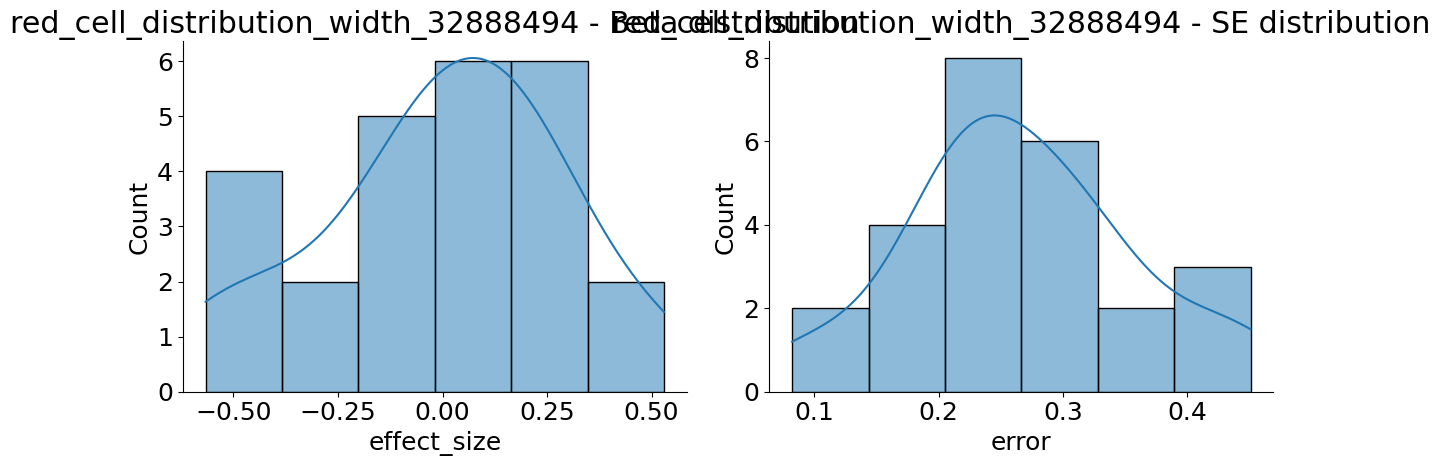

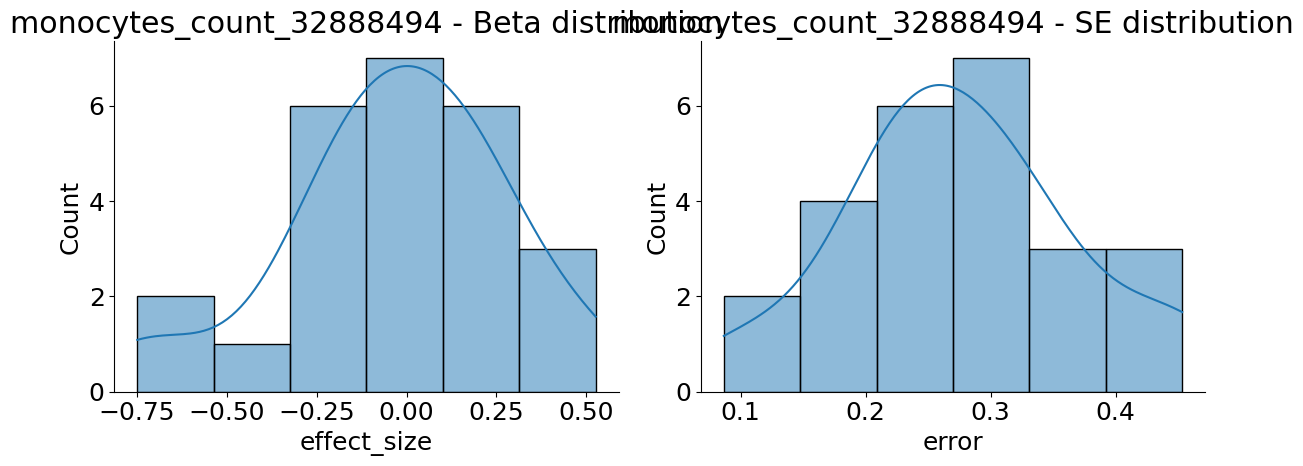

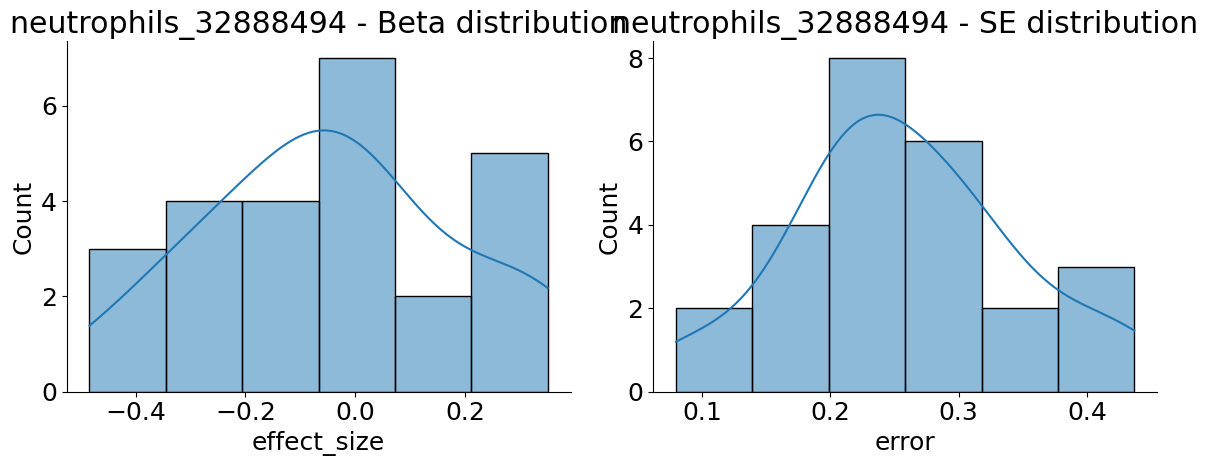

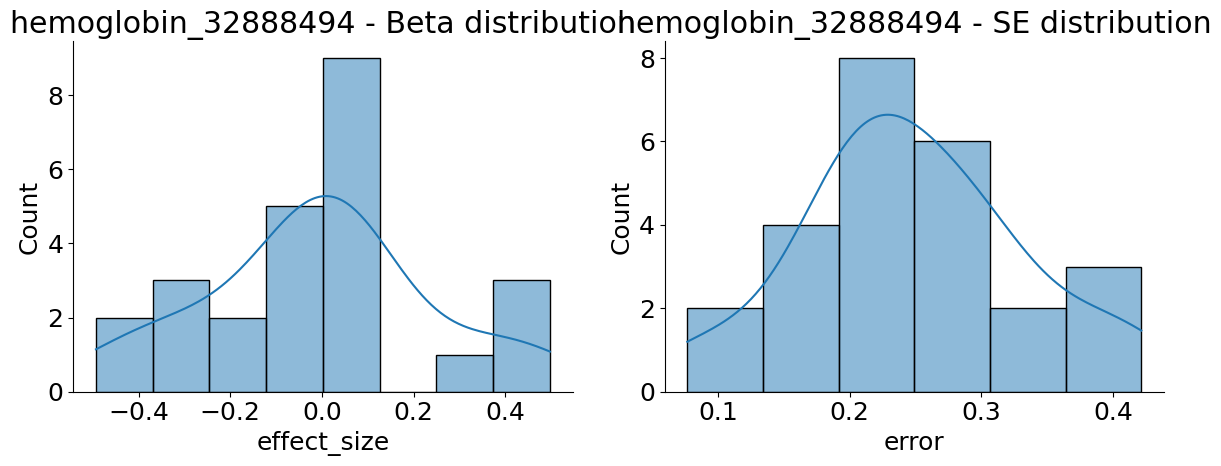

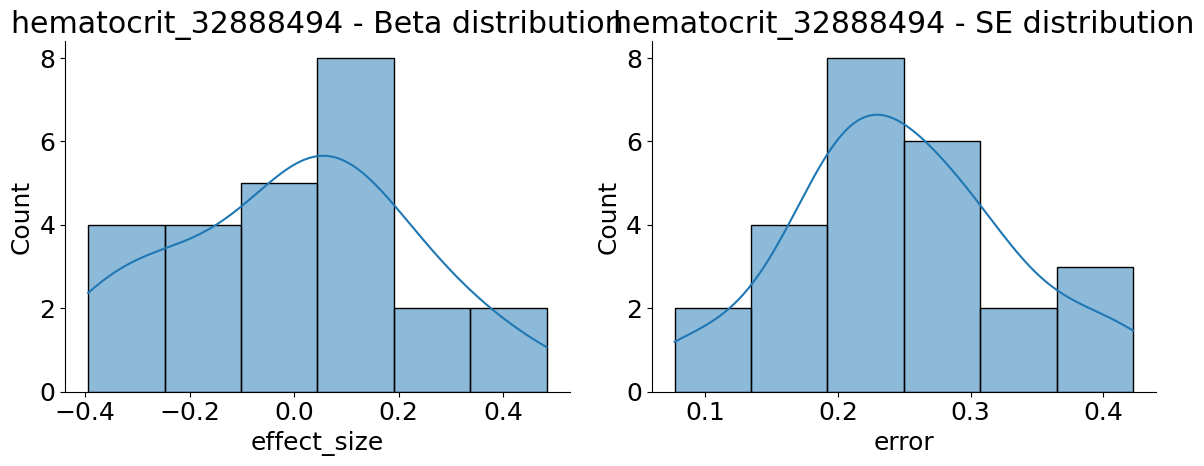

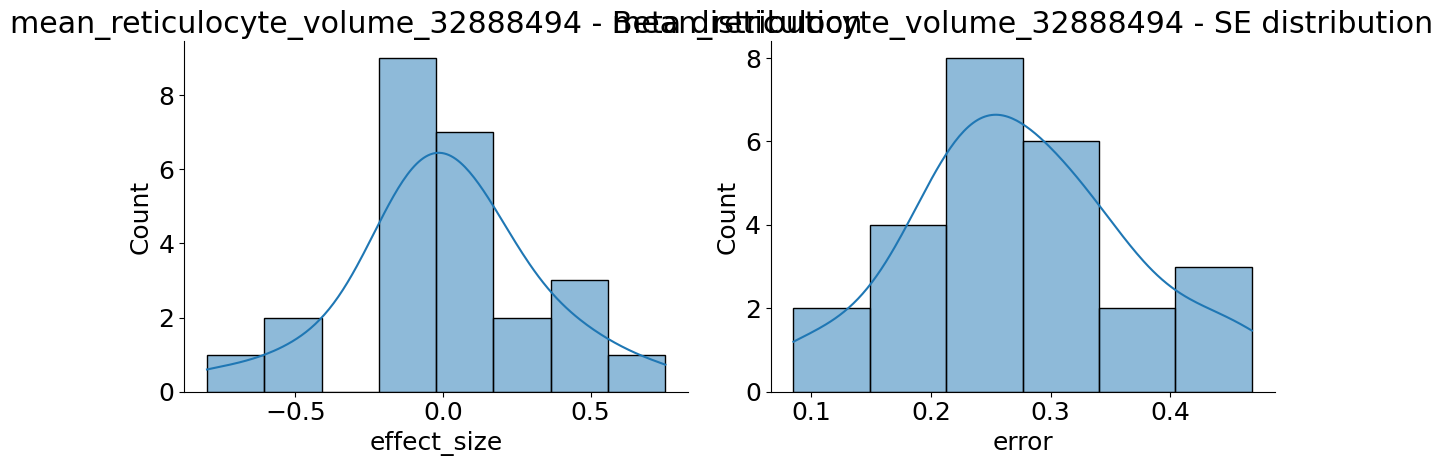

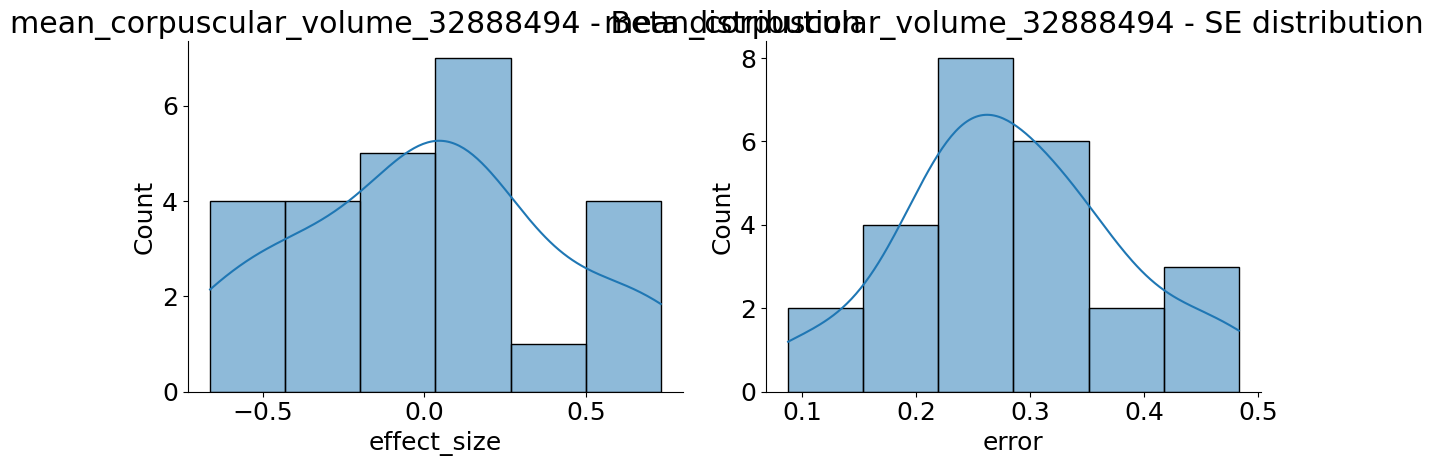

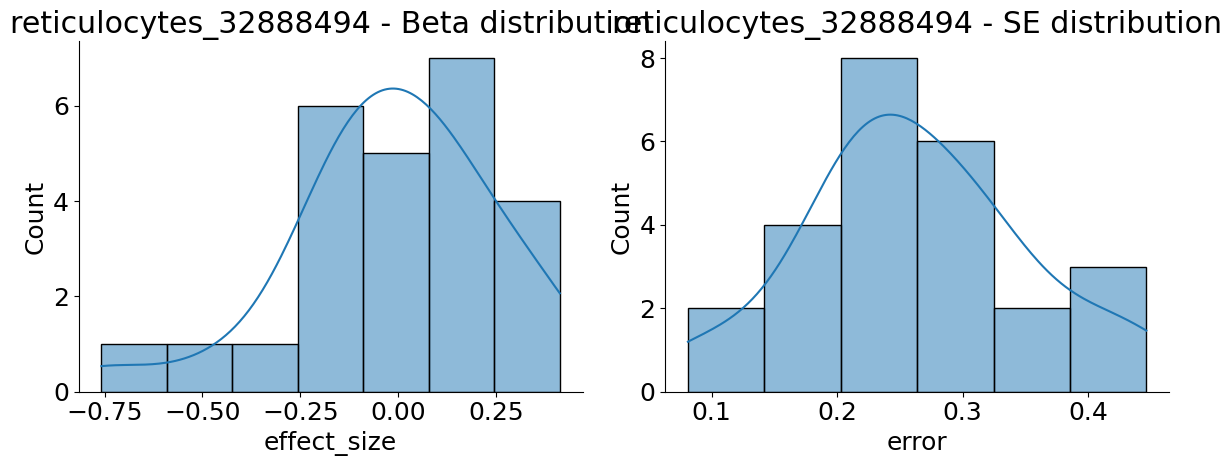

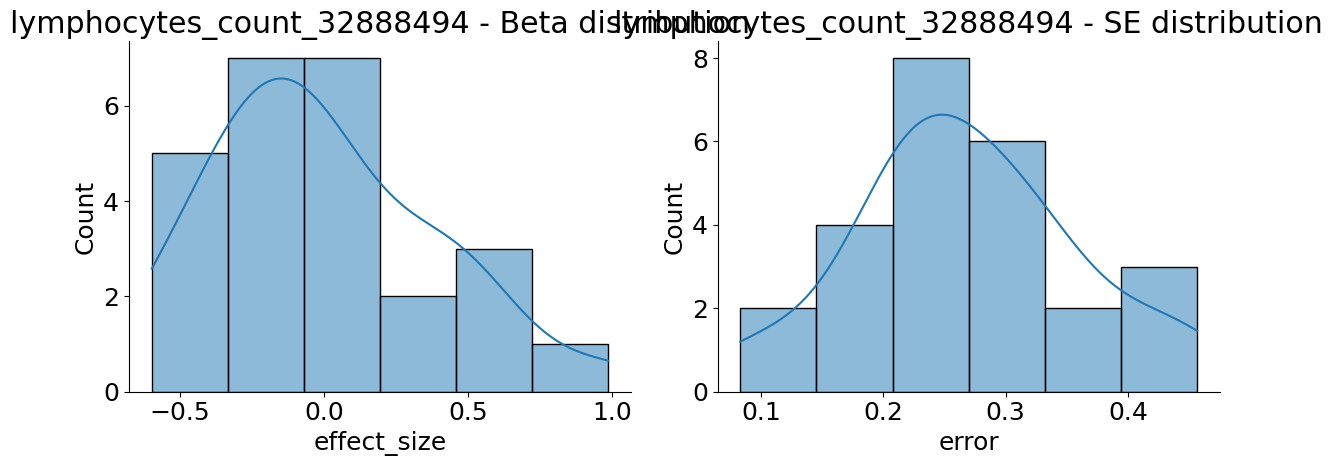

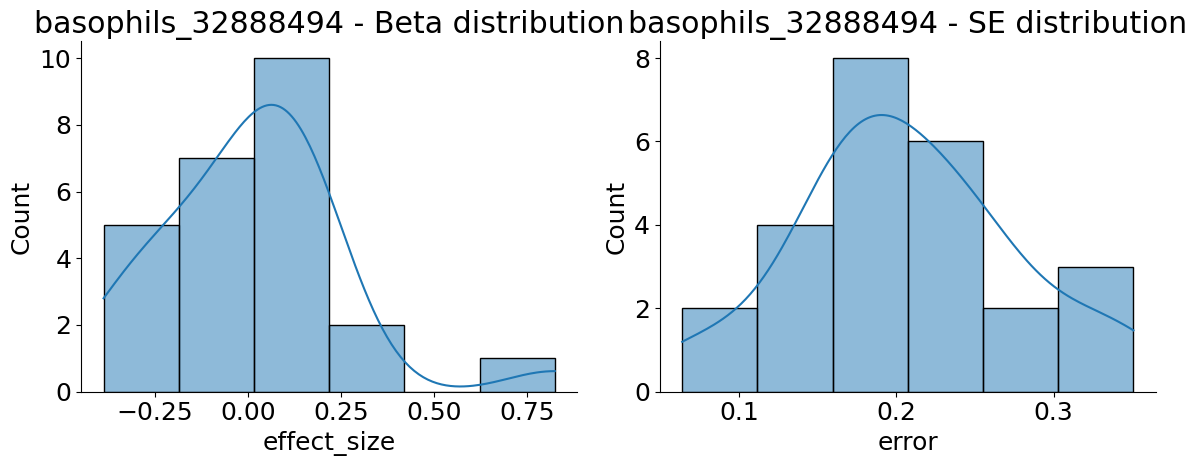

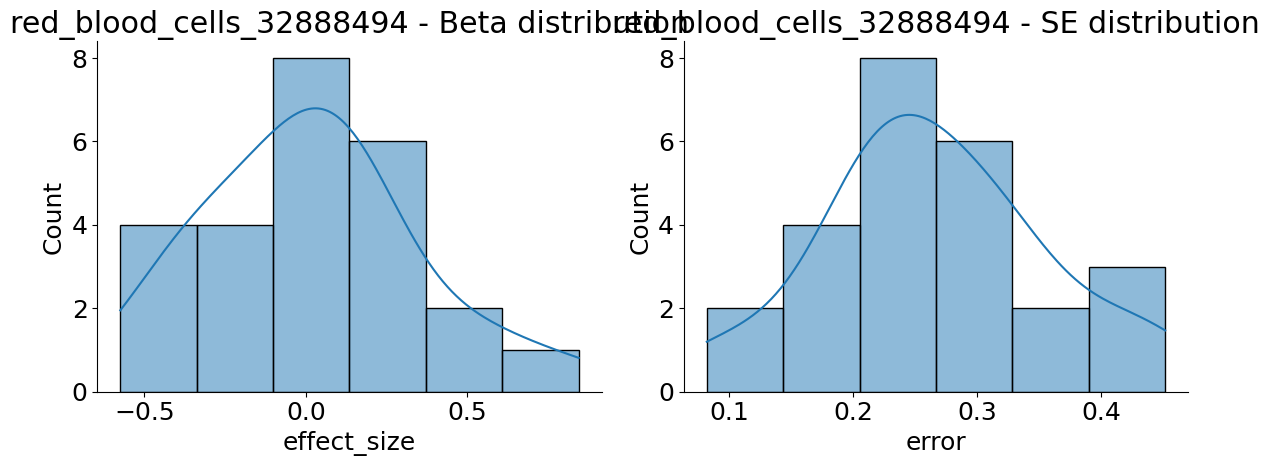

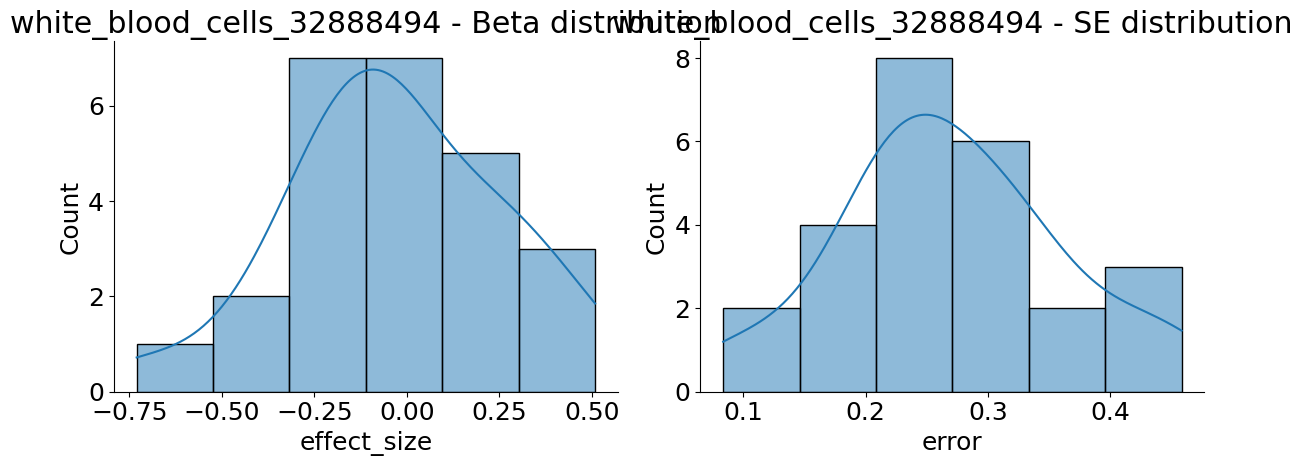

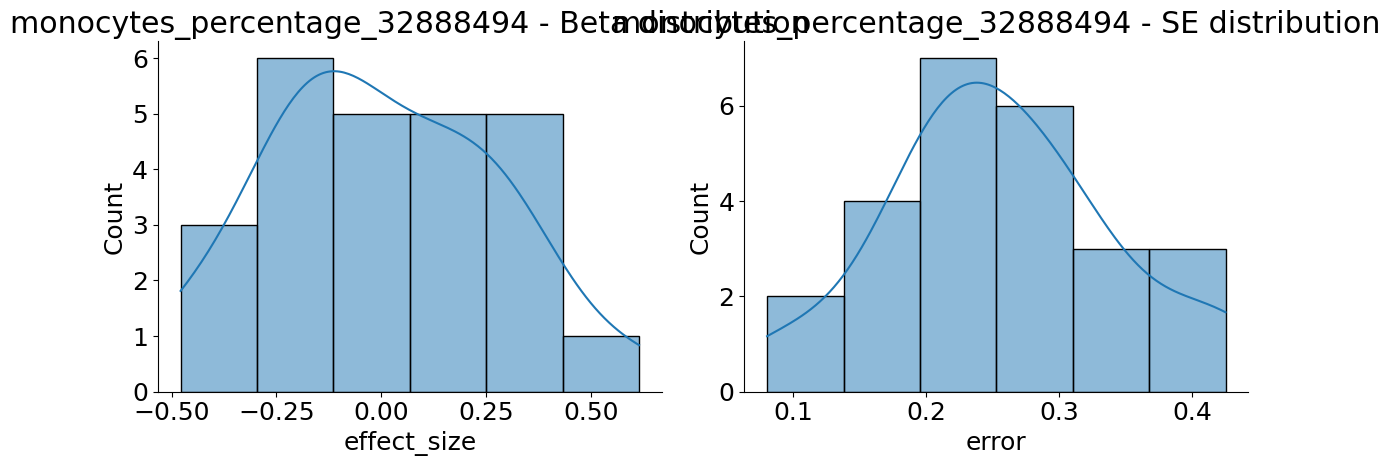

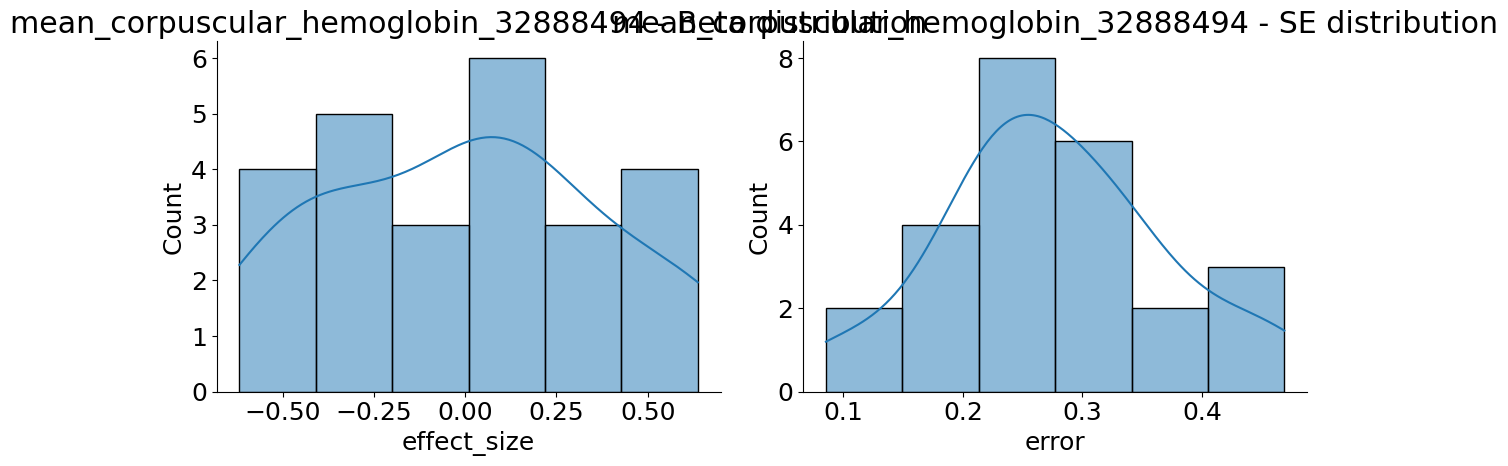

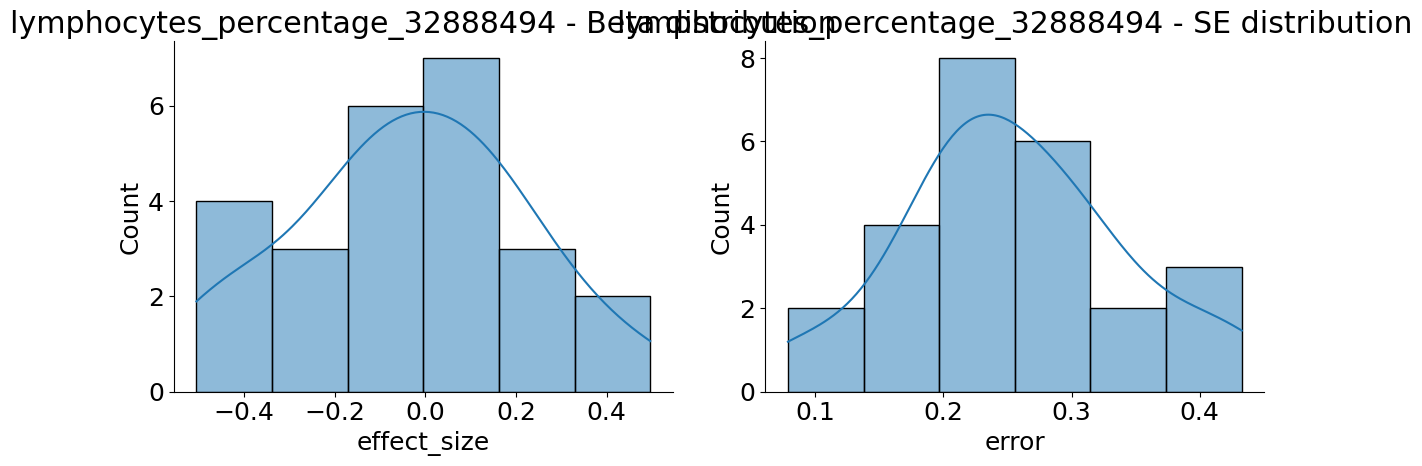

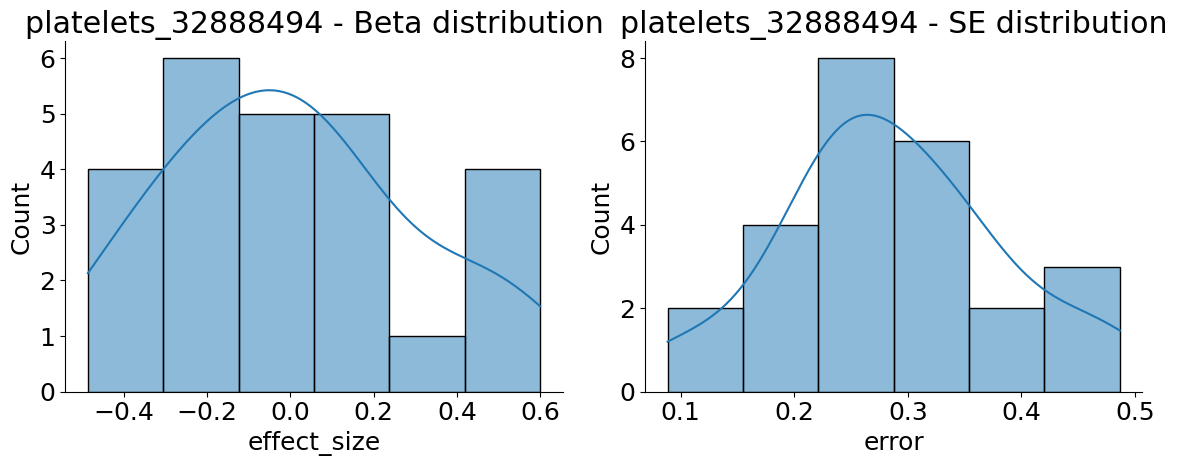

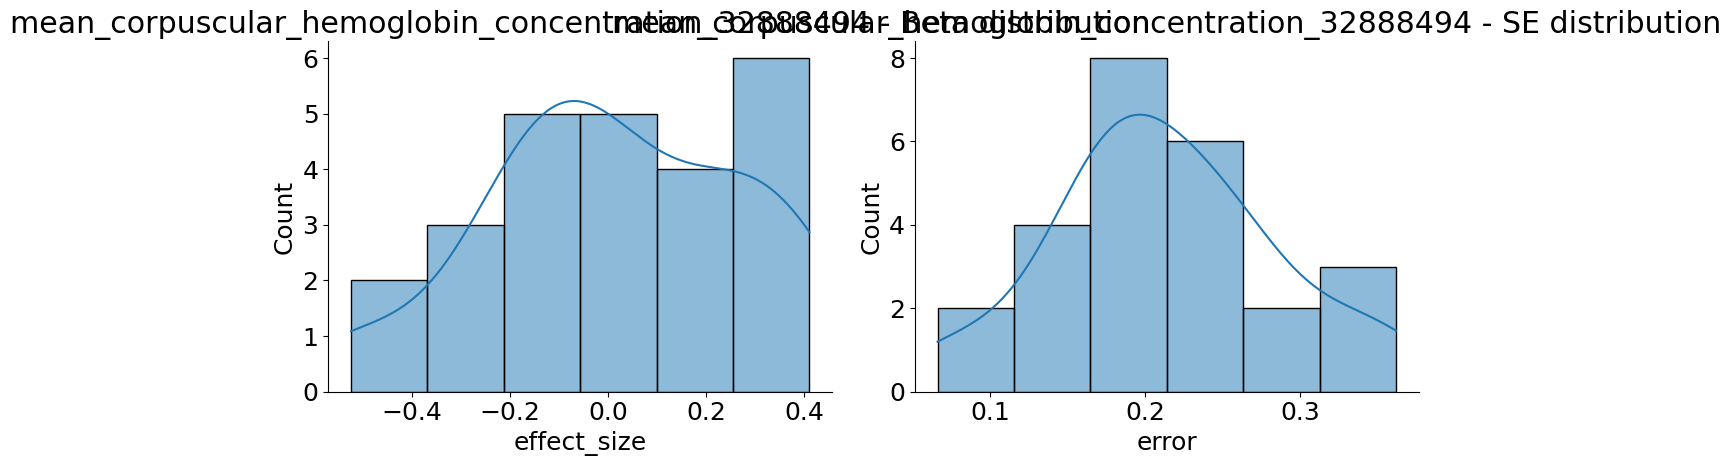

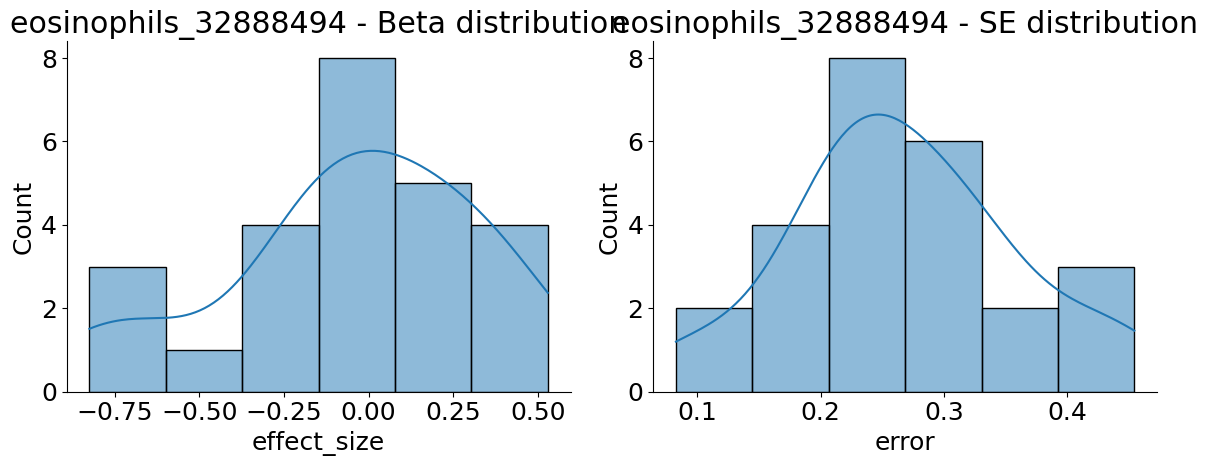

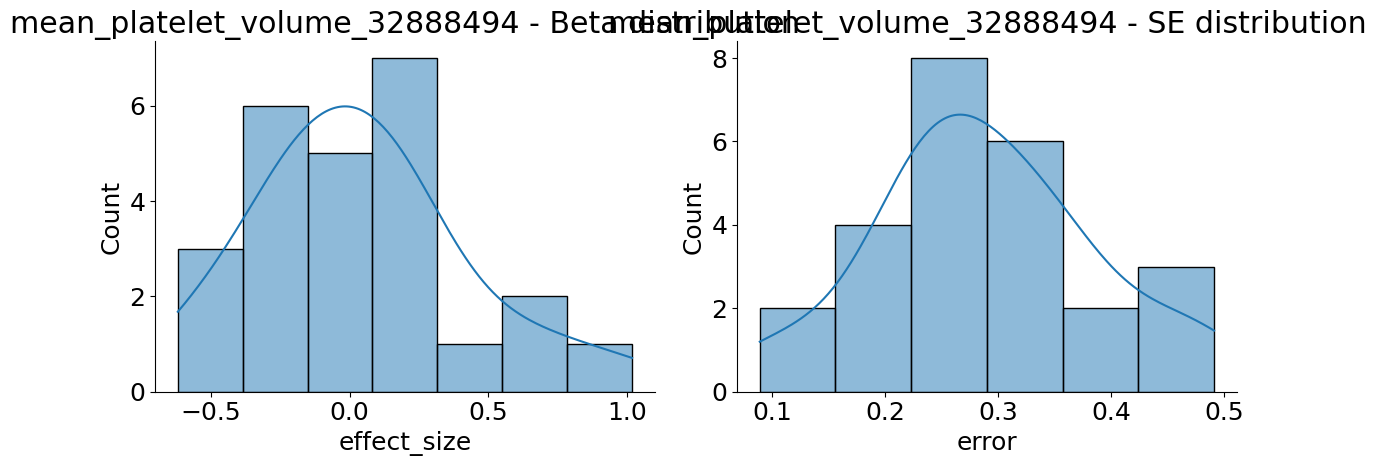

In [27]:
# plot histogram of beta and SE per trait
for trait in magma_res_df['trait'].unique():
    subset = magma_res_df[magma_res_df['trait'] == trait]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.histplot(subset['effect_size'], kde=True, ax=axes[0])
    axes[0].set_title(f'{trait} - Beta distribution')
    sns.histplot(subset['error'], kde=True, ax=axes[1])
    axes[1].set_title(f'{trait} - SE distribution')
    plt.tight_layout()
    plt.show()

Compare downstream DEG responses

In [28]:
gene_name = 'EHD4'
pattern = rf"_g{re.escape(gene_name)}_(?:.*)\.h5ad$"
print(pattern)
regex = re.compile(pattern, flags=re.IGNORECASE)

_gEHD4_(?:.*)\.h5ad$


In [29]:
def read_h5ad(gene: str, results_dir: str) -> sc.AnnData:
    # list all files in results_dir that contain the gene name using regex m = re.search(r"adata_g(.*?)_ssrc", fname)
    pattern = rf"adata_g{gene}_ssrc_.*\.h5ad$"

    file_paths = [
        entry.path
        for entry in os.scandir(results_dir)
        if entry.is_file() and re.search(pattern, entry.name)
    ]
    if len(file_paths) == 0:
        print(f"No files found for gene {gene}")
    else:
        for file_path in file_paths:
            print(f"Found file for gene {gene}: {file_path}")
    adata = sc.read_h5ad(file_paths[0])
    return adata

In [30]:
results_dir = '/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/perturbation_5k'

In [31]:
def concat_perturbed_adata(adata):
    """Concatenate two AnnData objects along observations (cells)."""
    pred_adata = adata.copy()
    pred_adata.X = pred_adata.layers['pred_counts']
    combined_adata = pred_adata.concatenate(
        adata,
        batch_key='status',
        batch_categories=['control', 'perturbed'],
        index_unique=None
    )
    sc.pp.normalize_total(combined_adata, target_sum=1e4)
    sc.pp.log1p(combined_adata)
    return combined_adata


In [32]:
def score_gene_sets(adata: ad.AnnData, gene_sets: dict):
    for gs_name, gs_genes in gene_sets.items():
        # skip if gs_name_score already in adata.obs
        if gs_name+'_score' in adata.obs.columns:
            print(f"Skipping {gs_name}, already scored.")
            continue
        sc.tl.score_genes(adata, gene_list=gs_genes, score_name=gs_name+'_score', use_raw=False)

In [33]:
def compute_delta_scores_per_celltype(perturbed_obs, gene_sets: dict):
    mean_delta_scores = {}
    overall_mean_delta_scores = {}
    for cell_type in perturbed_obs['celltype_v2'].unique():
        # compute mean delta score for each gene set in this cell type
        for gs_name in gene_sets.keys():
            mean_delta = perturbed_obs[perturbed_obs['celltype_v2'] == cell_type][gs_name+'_delta_score'].median()
            print(cell_type, gs_name, mean_delta)
            
            mean_delta_scores[(cell_type, gs_name)] = mean_delta
    for gs_name in gene_sets.keys():
        overall_mean = perturbed_obs[[gs_name+'_delta_score' for gs_name in gene_sets.keys()]].median()
        overall_mean_delta_scores[gs_name] = overall_mean[gs_name+'_delta_score']
    return mean_delta_scores, overall_mean_delta_scores

In [34]:
def score_gene_sets(adata: ad.AnnData, gene_sets: dict):
    for gs_name, gs_genes in gene_sets.items():
        # skip if gs_name_score already in adata.obs
        if gs_name+'_score' in adata.obs.columns:
            print(f"Skipping {gs_name}, already scored.")
            continue
        sc.tl.score_genes(adata, gene_list=gs_genes, score_name=gs_name+'_score', use_raw=False)

In [35]:
def compute_delta_scores(adata: ad.AnnData, gene_sets: dict):
    pert = adata[adata.obs["status"] == "perturbed"].obs.copy()
    ctrl = adata[adata.obs["status"] == "control"].obs.copy()

    # ensure 1:1 pairing by cell_idx, same order
    pert = pert.sort_values("cell_idx")
    ctrl = ctrl.sort_values("cell_idx")

    assert pert["cell_idx"].to_numpy().tolist() == ctrl["cell_idx"].to_numpy().tolist()

    for gs in gene_sets.keys():
        pert[f"{gs}_delta_score"] = (
            pert[f"{gs}_score"].to_numpy() - ctrl[f"{gs}_score"].to_numpy()
        )

    return pert

In [36]:
# find relevant gene sets to score perturbations
reactome_2024 = gp.get_library(name='Reactome_Pathways_2024', organism='Human')
go_bio = gp.get_library(name='GO_Biological_Process_2025', organism='Human')
go_cell = gp.get_library(name='GO_Cellular_Component_2025', organism='Human')
msigdb = gp.get_library(name='MSigDB_Hallmark_2020', organism='Human')

In [37]:
# unify gene set keys in msigdb
msigdb = {k.replace("HALLMARK_",""):v for k,v in msigdb.items()}
# make everything uppercase and replace spaces with underscores
msigdb = {k.upper().replace(" ","_"): [gene.upper() for gene in v] for k,v in msigdb.items()}

In [38]:
[x for x in go_bio if x.startswith('Ant')]

['Anterior/Posterior Axis Specification (GO:0009948)',
 'Anterior/Posterior Axis Specification, Embryo (GO:0008595)',
 'Anterior/Posterior Pattern Specification (GO:0009952)',
 'Anterograde Axonal Protein Transport (GO:0099641)',
 'Anterograde Axonal Transport (GO:0008089)',
 'Anterograde Dendritic Transport (GO:0098937)',
 'Anterograde Dendritic Transport of Neurotransmitter Receptor Complex (GO:0098971)',
 'Anterograde Synaptic Vesicle Transport (GO:0048490)',
 'Anterograde Trans-Synaptic Signaling (GO:0098916)',
 'Antibacterial Humoral Response (GO:0019731)',
 'Antibacterial Innate Immune Response (GO:0140367)',
 'Antibody-Dependent Cellular Cytotoxicity (GO:0001788)',
 'Antifungal Humoral Response (GO:0019732)',
 'Antifungal Innate Immune Response (GO:0061760)',
 'Antigen Processing and Presentation of Endogenous Peptide Antigen (GO:0002483)',
 'Antigen Processing and Presentation of Endogenous Peptide Antigen via MHC Class I (GO:0019885)',
 'Antigen Processing and Presentation of 

In [39]:
hspc_gene_sets = {
    # 'hsc_differentiation': go_bio['Hematopoietic Stem Cell Differentiation (GO:0060218)'],
    # 'hsc_differentiation_marker_new': ["HLF", "MEIS1", "MSI2", "CD34", "SPINK2", "AVP", "HOXA9"],
    'lymphocyte_differentiation': go_bio['Lymphocyte Differentiation (GO:0030098)'],
    'bcell': reactome_2024['Signaling by the B Cell Receptor (BCR)'],
    'megakaryocyte_differentiation': go_bio['Megakaryocyte Differentiation (GO:0030219)'],
    # 'platelet_activation': reactome_2024['Platelet Activation, Signaling and Aggregation'],
    'eythrocyte differentiation': go_bio['Erythrocyte Differentiation (GO:0030218)'],
    # 'heme_metabolism': msigdb['HEME_METABOLISM'],
    # 'erythrocyte development': go_bio['Erythrocyte Development (GO:0048821)'],
    # 'e2f_targets': msigdb['E2F_TARGETS'],
    # 'g2m_checkpoint': msigdb['G2-M_CHECKPOINT'],
    # 'myeloid_differentiation': go_bio['Myeloid Cell Differentiation (GO:0030099)'],
    
    # 'tnfa_signaling': msigdb['TNF-ALPHA_SIGNALING_VIA_NF-KB'],
    # 'oxidative_phosphorylation': msigdb['OXIDATIVE_PHOSPHORYLATION'],
    'monocyte_differentiation': go_bio['Monocyte Differentiation (GO:0030224)'],
    # 'neutrophil_activation': go_bio['Neutrophil Activation (GO:0042119)'],
    'antigen_presentation': go_bio['Antigen Processing and Presentation of Peptide Antigen via MHC Class II (GO:0002495)'],
    
}


In [40]:
# run full pipeline for gene in ['GATA1', 'KLF1', 'TAL1']:
perturbed_obs_dict = {}
mean_delta_scores_dict = {}
overall_mean_delta_scores_dict = {}
deg_results_dict = {}

genes_to_compare = ['KLF1', 'JCHAIN', 'CEBPA', 'CEBPE', 'CSF3R', 'CSF1R', 'HNMT']
# genes_to_compare = ['MPO','TAL1','DNTT','CEBPE','CEBPA', 'CSF3R']
for gene in genes_to_compare:
    adata = read_h5ad(gene, results_dir)
    # adata = adata[adata.obs.celltype_v2.isin(['DC_pre', 'Mono_pre', 'pDC', 'Macrophage'])]
    pred_adata = concat_perturbed_adata(adata)
        # --- DEG computation ---
    sc.tl.rank_genes_groups(
        pred_adata,
        groupby="status",
        reference="control",
        method="wilcoxon",
        n_genes=pred_adata.shape[1]
    )

    # deg_df = sc.get.rank_genes_groups_df(
    #     pred_adata,
    #     group="perturbed"
    # )

    # deg_df["perturbation_gene"] = gene
    # deg_results_dict[gene] = deg_df
    score_gene_sets(pred_adata, hspc_gene_sets)
    perturbed_obs = compute_delta_scores(pred_adata, hspc_gene_sets)
    perturbed_obs_dict[gene] = perturbed_obs
    mean_delta_scores, overall_mean_delta_scores = compute_delta_scores_per_celltype(perturbed_obs, hspc_gene_sets)
    mean_delta_scores['gene'] = gene
    mean_delta_scores_dict[gene] = mean_delta_scores
    overall_mean_delta_scores_dict[gene] = overall_mean_delta_scores

Found file for gene KLF1: /lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/perturbation_5k/20250719-15:42_minference_adata_gKLF1_ssrc_tmask.h5ad


/tmp/ipykernel_1952830/1245321105.py:5: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_adata = pred_adata.concatenate(
/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


       'PIK3R3', 'PIK3R2', 'PTPRJ', 'DCAF1', 'SLC39A7', 'NHEJ1', 'FNIP1',
       'CR2', 'TCF7L1', 'SLC25A5', 'ITGB1', 'GPR89A', 'HDAC4', 'CLSTN1',
       'ADGRG3', 'JAK3'],
      dtype='object')
       'PPIA', 'PSMC6', 'STIM1', 'PSMC4',
       ...
       'HRAS', 'IGKV1-33', 'IGLC2', 'FYN', 'IGLC3', 'IKBKG', 'IGHV3-7',
       'IGLC1', 'NCK1', 'IGHV3-9'],
      dtype='object', length=132)
       'TSPO2', 'HCLS1', 'ACIN1', 'CDIN1', 'SLC25A5', 'INHA', 'ALAS1', 'UBA5',
       'HSCB', 'SLC1A5', 'UFL1', 'RACGAP1', 'RPS19', 'ATP5IF1', 'CASP3',
       'FLVCR1', 'LYAR', 'RPS14', 'SH2B3', 'CDK5RAP3', 'JAK2'],
      dtype='object')
       'CTSE'],
      dtype='object')
BaEoMa lymphocyte_differentiation 0.0003024500069225555
BaEoMa bcell 0.0934118919955787
BaEoMa megakaryocyte_differentiation -0.2506010572468861
BaEoMa eythrocyte differentiation -0.15705370176348937
BaEoMa monocyte_differentiation 0.1768781916885206
BaEoMa antigen_presentation 0.2733359170503503
Mono_pre lymphocyte_differentiation 

/tmp/ipykernel_1952830/1245321105.py:5: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_adata = pred_adata.concatenate(
/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


       'PIK3R3', 'PIK3R2', 'PTPRJ', 'DCAF1', 'SLC39A7', 'NHEJ1', 'FNIP1',
       'CR2', 'TCF7L1', 'SLC25A5', 'ITGB1', 'GPR89A', 'HDAC4', 'CLSTN1',
       'ADGRG3', 'JAK3'],
      dtype='object')
       'PPIA', 'PSMC6', 'STIM1', 'PSMC4',
       ...
       'HRAS', 'IGKV1-33', 'IGLC2', 'FYN', 'IGLC3', 'IKBKG', 'IGHV3-7',
       'IGLC1', 'NCK1', 'IGHV3-9'],
      dtype='object', length=132)
       'TSPO2', 'HCLS1', 'ACIN1', 'CDIN1', 'SLC25A5', 'INHA', 'ALAS1', 'UBA5',
       'HSCB', 'SLC1A5', 'UFL1', 'RACGAP1', 'RPS19', 'ATP5IF1', 'CASP3',
       'FLVCR1', 'LYAR', 'RPS14', 'SH2B3', 'CDK5RAP3', 'JAK2'],
      dtype='object')
       'CTSE'],
      dtype='object')
Immature_B lymphocyte_differentiation -0.2059713456967864
Immature_B bcell -0.2528412901874864
Immature_B megakaryocyte_differentiation 0.06131400005249471
Immature_B eythrocyte differentiation -0.006171333344503371
Immature_B monocyte_differentiation 0.025094097573621604
Immature_B antigen_presentation 0.018626559863106296
Pro_B ly

...

       'PIK3R3', 'PIK3R2', 'PTPRJ', 'DCAF1', 'SLC39A7', 'NHEJ1', 'FNIP1',
       'CR2', 'TCF7L1', 'SLC25A5', 'ITGB1', 'GPR89A', 'HDAC4', 'CLSTN1',
       'ADGRG3', 'JAK3'],
      dtype='object')
       'PPIA', 'PSMC6', 'STIM1', 'PSMC4',
       ...
       'HRAS', 'IGKV1-33', 'IGLC2', 'FYN', 'IGLC3', 'IKBKG', 'IGHV3-7',
       'IGLC1', 'NCK1', 'IGHV3-9'],
      dtype='object', length=132)
       'TSPO2', 'HCLS1', 'ACIN1', 'CDIN1', 'SLC25A5', 'INHA', 'ALAS1', 'UBA5',
       'HSCB', 'SLC1A5', 'UFL1', 'RACGAP1', 'RPS19', 'ATP5IF1', 'CASP3',
       'FLVCR1', 'LYAR', 'RPS14', 'SH2B3', 'CDK5RAP3', 'JAK2'],
      dtype='object')
       'CTSE'],
      dtype='object')
Mono_pre lymphocyte_differentiation 0.009085975558538933
Mono_pre bcell -0.012185380748981456
Mono_pre megakaryocyte_differentiation 0.013912159792134476
Mono_pre eythrocyte differentiation -0.03179187339085801
Mono_pre monocyte_differentiation -0.10907262174979504
Mono_pre antigen_presentation -0.35623044720635433
Immature_B lympho

/tmp/ipykernel_1952830/1245321105.py:5: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_adata = pred_adata.concatenate(
/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


       'PIK3R3', 'PIK3R2', 'PTPRJ', 'DCAF1', 'SLC39A7', 'NHEJ1', 'FNIP1',
       'CR2', 'TCF7L1', 'SLC25A5', 'ITGB1', 'GPR89A', 'HDAC4', 'CLSTN1',
       'ADGRG3', 'JAK3'],
      dtype='object')
       'PPIA', 'PSMC6', 'STIM1', 'PSMC4',
       ...
       'HRAS', 'IGKV1-33', 'IGLC2', 'FYN', 'IGLC3', 'IKBKG', 'IGHV3-7',
       'IGLC1', 'NCK1', 'IGHV3-9'],
      dtype='object', length=132)
       'TSPO2', 'HCLS1', 'ACIN1', 'CDIN1', 'SLC25A5', 'INHA', 'ALAS1', 'UBA5',
       'HSCB', 'SLC1A5', 'UFL1', 'RACGAP1', 'RPS19', 'ATP5IF1', 'CASP3',
       'FLVCR1', 'LYAR', 'RPS14', 'SH2B3', 'CDK5RAP3', 'JAK2'],
      dtype='object')
       'CTSE'],
      dtype='object')
Mono_pre lymphocyte_differentiation -0.008223513624216361
Mono_pre bcell -0.018554331031951032
Mono_pre megakaryocyte_differentiation 0.015223594512424277
Mono_pre eythrocyte differentiation -0.03983869986646135
Mono_pre monocyte_differentiation -0.05831117607412262
Mono_pre antigen_presentation -0.27433187451443514
Immature_B lymph

/tmp/ipykernel_1952830/1245321105.py:5: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_adata = pred_adata.concatenate(
/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


       'PIK3R3', 'PIK3R2', 'PTPRJ', 'DCAF1', 'SLC39A7', 'NHEJ1', 'FNIP1',
       'CR2', 'TCF7L1', 'SLC25A5', 'ITGB1', 'GPR89A', 'HDAC4', 'CLSTN1',
       'ADGRG3', 'JAK3'],
      dtype='object')
       'PPIA', 'PSMC6', 'STIM1', 'PSMC4',
       ...
       'HRAS', 'IGKV1-33', 'IGLC2', 'FYN', 'IGLC3', 'IKBKG', 'IGHV3-7',
       'IGLC1', 'NCK1', 'IGHV3-9'],
      dtype='object', length=132)
       'TSPO2', 'HCLS1', 'ACIN1', 'CDIN1', 'SLC25A5', 'INHA', 'ALAS1', 'UBA5',
       'HSCB', 'SLC1A5', 'UFL1', 'RACGAP1', 'RPS19', 'ATP5IF1', 'CASP3',
       'FLVCR1', 'LYAR', 'RPS14', 'SH2B3', 'CDK5RAP3', 'JAK2'],
      dtype='object')
       'CTSE'],
      dtype='object')
Mono_pre lymphocyte_differentiation -0.0030313053050888272
Mono_pre bcell 0.000183470574965372
Mono_pre megakaryocyte_differentiation 0.01936334971318246
Mono_pre eythrocyte differentiation -0.04270810705404904
Mono_pre monocyte_differentiation -0.14654438192629093
Mono_pre antigen_presentation -0.3042164952337225
Immature_B lymphoc

<Figure size 1000x600 with 0 Axes>

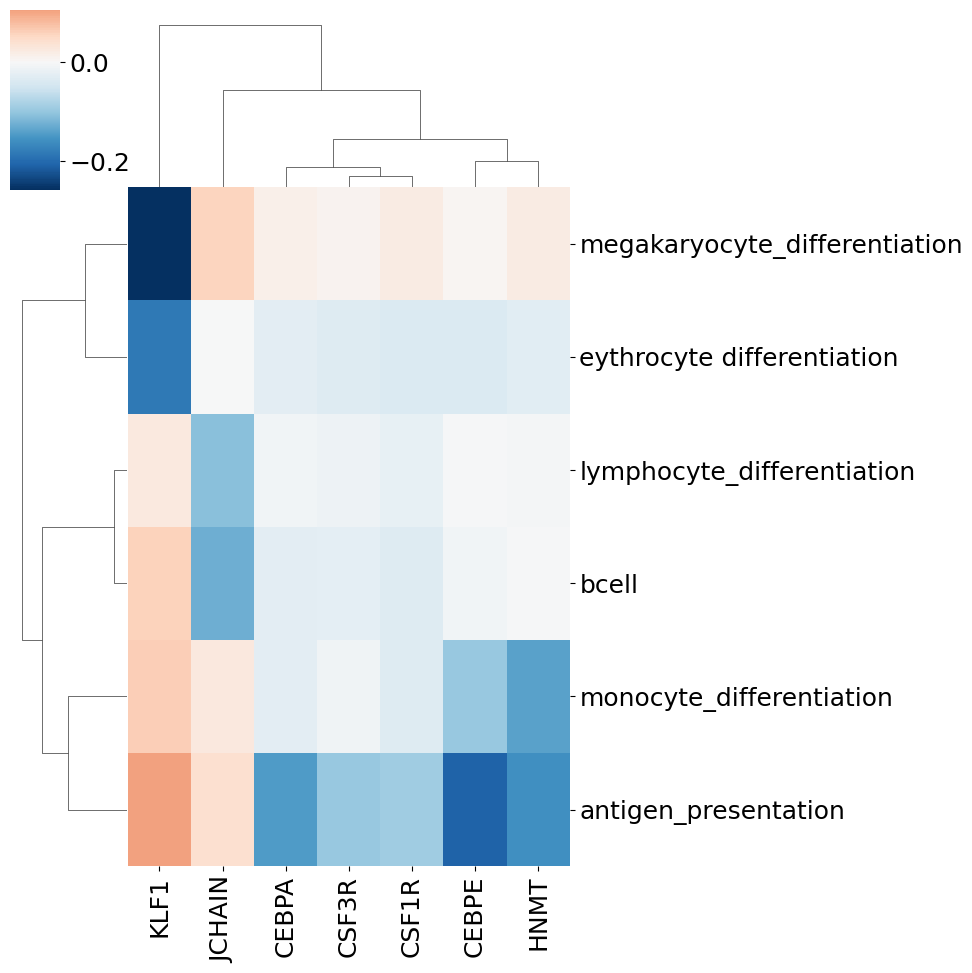

In [ ]:
delta_scores_df = pd.DataFrame(overall_mean_delta_scores_dict)
# plot heatmap of delta scores
plt.figure(figsize=(10, 6))
sns.clustermap(
    delta_scores_df,
    cmap='RdBu_r',
    center=0,
)
# save figure
plt.savefig(
    f"{res_dir}/HMNT_downstream_perturbation.pdf",
    dpi=300,
    bbox_inches="tight"
)